# ML — La Huella Conductual

A partir de un día de datos del collar, ¿se puede reconocer de qué perro se trata? Proyecto de Machine Learning con los datos de los collares Tractive de tres perros que conviven, desde el análisis exploratorio hasta el modelo final.

**Cómo está organizado el proyecto**

- `src/notebooks/00_comprension_datos.ipynb` — qué contienen los JSON exportados de los collares, cómo se pasan a tablas y el diccionario de datos.
- `main.ipynb` — este notebook: EDA, modelado y evaluación.

## Paso 1: Entendiendo el problema

**Problema de negocio.** Los dueños y el veterinario quieren detectar a tiempo cambios en el comportamiento de cada perro. Un aviso personalizado ("hoy cherry no se comporta como de costumbre") solo tiene sentido si los datos del collar son lo bastante propios de cada perro como para darle su propia referencia. Si los perros se comportaran de forma parecida, bastaría con un umbral común.

**Pregunta que responde el modelo:** a partir de un día de datos del collar, ¿se puede reconocer de qué perro se trata? Si la respuesta es sí, cada perro tiene una referencia propia, y las variables que más usa el modelo son las señales que conviene vigilar.

**Objetivo de modelado:** clasificación supervisada con tres clases. La target es `perro` (cherry, coco o plum) y cada fila es un día de un perro.

**Plan de acción**

| Resultado del modelo | Decisión |
|---|---|
| Reconoce bien a cada perro en días que no ha visto | Avisos personalizados, con la referencia de cada perro y vigilando las señales más importantes del modelo |
| No consigue distinguirlos | Avisos con un umbral común para los tres |

**Uso futuro.** Un día en que un perro no se parezca a sí mismo según el modelo podría marcarse como atípico. Validarlo exigiría un historial veterinario que hoy no existe, así que queda fuera de este proyecto.

**¿Por qué Machine Learning?** Las señales de un perro cambian mucho de un día a otro, así que es probable que una sola no baste para reconocerlo. Un modelo puede aprender a combinar varias. El EDA comprueba antes si combinadas separan mejor a los perros.

**Alcance: tres perros.** Cherry, coco y plum llevan el mismo modelo de collar. El de kiwi, el cuarto perro de la casa, es de otro modelo y no tiene sensor de ladridos, así que queda fuera para que el modelo no aprenda a reconocer el dispositivo en lugar del perro. Cada perro ha llevado siempre su propio collar.

### Hipótesis del EDA

El EDA contrasta cuatro hipótesis, cada una con consecuencias para el modelo o para los avisos:

| | Hipótesis | Si se confirma | Si se refuta |
|---|---|---|---|
| **H1** | La frecuencia cardíaca (FC) y respiratoria (FR) en reposo difieren entre los perros | Son candidatas principales a features | Buscar la huella en la actividad y los ladridos |
| **H2** | En los días más calurosos los perros están menos activos | Tener en cuenta la época del año al evaluar con días posteriores y en los avisos | No hace falta tener en cuenta la época del año |
| **H3** | Los perros que conviven ladran en las mismas franjas horarias más de lo esperable por azar | Parte de los ladridos responde a la casa: comprobar que, aun así, distinguen a cada perro | Los ladridos son una señal propia de cada perro |
| **H4** | Los perros están más activos en fin de semana, cuando los dueños están en casa | En los avisos, comparar cada día con los del mismo tipo (laborable o fin de semana) | No hace falta separar laborables y fines de semana |

> **Nota metodológica:** antes de formular las hipótesis se revisó qué contenían los datos (`00_comprension_datos.ipynb`). Para no sesgar el análisis, las hipótesis hablan de mecanismos generales y no de perros o valores concretos vistos en esa revisión.

**Datos.** Tres datasets generados a partir de los exports de los collares con `src/utils/data_loader.py`: uno con una fila por perro y día, otro con los ladridos por franjas de 30 minutos y otro con la actividad por hora. Ninguno contiene coordenadas.

## Paso 2: Carga de datos y tabla de variables

In [1]:
import pickle
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src.utils.bootcampviztools import (pinta_distribucion_categoricas, plot_combined_graphs,
                                        plot_grouped_histograms)

# seaborn 0.13 usa una opción de matplotlib 3.11 marcada como obsoleta; no afecta a los gráficos
warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid")

Se cargan los tres datasets y se quedan los días de cherry, coco y plum:

In [2]:
TARGET = "perro"
PERROS = ["cherry", "coco", "plum"]

crudo = pd.read_csv("src/data_sample/diario_perros.csv", parse_dates=["fecha"])
franjas = pd.read_csv("src/data_sample/ladridos_30min.csv", parse_dates=["fecha"])
horaria = pd.read_csv("src/data_sample/actividad_horaria.csv", parse_dates=["fecha"])
print("Con los cuatro perros -> diario:", crudo.shape, "| franjas:", franjas.shape, "| horaria:", horaria.shape)

crudo = crudo[crudo["perro"] != "kiwi"].copy()
horaria = horaria[horaria["perro"] != "kiwi"]
print("Sin kiwi -> diario:", crudo.shape, "| franjas:", franjas.shape, "| horaria:", horaria.shape)
crudo.head()

Con los cuatro perros -> diario: (898, 24) | franjas: (27312, 4) | horaria: (21552, 9)
Sin kiwi -> diario: (570, 24) | franjas: (27312, 4) | horaria: (13680, 9)


,perro,fecha,min_reposo,min_calma,min_activo,min_intenso,min_sin_datos,min_otros,ladridos_total,ladridos_franjas,...,fc_n,fr_media,fr_min,fr_max,fr_n,temp_disp_media,temp_disp_max,dia_semana,es_finde,mes
0,cherry,2026-02-22,240.183333,6.416667,7.950000,0.0,1185.450000,0.0,6.0,2.0,...,22.0,9.471429,7.0,14.0,70.0,21.909091,28,Sunday,True,2
1,cherry,2026-02-23,888.233333,85.266667,117.700000,0.0,348.800000,0.0,149.0,11.0,...,76.0,8.460938,5.0,20.0,128.0,27.000000,35,Monday,False,2
2,cherry,2026-02-24,933.016667,67.616667,108.600000,0.0,330.766667,0.0,289.0,15.0,...,71.0,7.847826,5.0,14.0,138.0,27.684211,32,Tuesday,False,2
3,cherry,2026-02-25,1014.400000,50.433333,87.466667,0.0,287.700000,0.0,565.0,19.0,...,86.0,7.922619,4.0,16.0,168.0,26.666667,35,Wednesday,False,2
4,cherry,2026-02-26,901.866667,79.583333,116.683333,0.0,341.866667,0.0,351.0,10.0,...,51.0,7.909677,5.0,16.0,155.0,27.333333,36,Thursday,False,2


Quedan 570 días de los tres perros. El dataset de ladridos por franja no cambia, porque kiwi no aparece en él.

**Tipos de dato**

In [3]:
crudo.dtypes

perro                            str
fecha                 datetime64[us]
min_reposo                   float64
min_calma                    float64
min_activo                   float64
min_intenso                  float64
min_sin_datos                float64
min_otros                    float64
ladridos_total               float64
ladridos_franjas             float64
ladridos_max_30min           float64
fc_media                     float64
fc_min                       float64
fc_max                       float64
fc_n                         float64
fr_media                     float64
fr_min                       float64
fr_max                       float64
fr_n                         float64
temp_disp_media              float64
temp_disp_max                  int64
dia_semana                       str
es_finde                        bool
mes                            int64
dtype: object

Las fechas se leen como fechas, las señales como números y `perro` como texto. Los conteos de ladridos salen como decimales porque un nulo obliga a pandas a usar `float`. No hace falta convertir nada.

### Tabla de variables

El diccionario completo de los tres datasets está en `00_comprension_datos.ipynb`, §8. Esta tabla resume qué papel tiene cada columna del dataset diario:

| Variable | Tipo | Papel | Motivo |
|---|---|---|---|
| `perro` | categórica | **target** | lo que se quiere predecir |
| `fecha` | fecha | ordenar y dividir los datos | es la misma para los tres perros cada día |
| `min_reposo`, `min_calma`, `min_activo`, `min_intenso` | numérica | candidata, como porcentaje | minutos del día en cada categoría de actividad; en la limpieza se pasan a porcentaje del tiempo medido |
| `fc_media`, `fc_min`, `fc_max` | numérica | candidata | frecuencia cardíaca en reposo |
| `fr_media`, `fr_min`, `fr_max` | numérica | candidata | frecuencia respiratoria en reposo |
| `ladridos_total`, `ladridos_franjas`, `ladridos_max_30min` | numérica | candidata | los tres collares tienen sensor de ladridos |
| `min_otros` | numérica | descartada | categoría casi inexistente (`00`, §4) |
| `min_sin_datos`, `fc_n`, `fr_n` | numérica | calidad del dato | describen cuánto midió el collar, no al perro; `min_sin_datos` sirve para filtrar días |
| `temp_disp_media`, `temp_disp_max` | numérica | contexto (H2) | cada collar envía sus lecturas de temperatura en distinta cantidad y a horas distintas, así que la media diaria no es comparable entre perros (`00`, §6) |
| `dia_semana`, `es_finde`, `mes` | categórica | contexto (H4) | son iguales para los tres perros cada día: no ayudan a distinguirlos |

Las candidatas se revisan en el EDA y la selección final se hace en el Paso 8.

## Paso 3: Limpieza

Se comprueba que los datos cumplen lo que dice el diccionario y se decide qué días usar. Son reglas fijas que se aplican a cada día por separado, como "al menos medio día medido", así que aplicarlas antes de dividir en train y test no traslada información del test a train.

### 3.1 Duplicados y días que faltan

In [4]:
print("Filas duplicadas (mismo perro y día):", crudo.duplicated(subset=["perro", "fecha"]).sum())

for perro in PERROS:
    datos_perro = crudo[crudo["perro"] == perro]
    dias_posibles = (datos_perro["fecha"].max() - datos_perro["fecha"].min()).days + 1
    print(f"{perro}: del {datos_perro['fecha'].min().date()} al {datos_perro['fecha'].max().date()} | "
          f"{len(datos_perro)} días registrados de {dias_posibles} posibles")

Filas duplicadas (mismo perro y día): 0
cherry: del 2026-02-22 al 2026-09-09 | 200 días registrados de 200 posibles
coco: del 2026-03-26 al 2026-09-10 | 169 días registrados de 169 posibles
plum: del 2026-02-22 al 2026-09-10 | 201 días registrados de 201 posibles


No hay duplicados ni faltan días. Coco empezó a llevar el collar un mes después que cherry y plum.

### 3.2 Nulos

In [5]:
nulos = crudo.isna().sum()
print(nulos[nulos > 0])

crudo["min_medidos"] = 1440 - crudo["min_sin_datos"]
print("\nDía con nulos:")
print(crudo[crudo["ladridos_total"].isna()][["perro", "fecha", "min_medidos"]])

ladridos_total        1
ladridos_franjas      1
ladridos_max_30min    1
dtype: int64

Día con nulos:
    perro      fecha  min_medidos
722  plum 2026-03-19   301.466667


Solo hay un día con nulos, en las tres columnas de ladridos de plum. Ese día el collar apenas midió unas horas, así que lo elimina el filtro del apartado siguiente y no hace falta rellenarlo.

### 3.3 ¿Cuánto midió el collar cada día?

Cada día tiene 1.440 minutos, pero parte de ese tiempo el collar no mide (carga, falta de cobertura). Si un día apenas se midió, sus cifras no son fiables.

Además, el loader ya ha convertido en "sin datos" unos bloques imposibles de actividad intensa, de hasta 13 horas seguidas (`00_comprension_datos.ipynb`, §4.1).

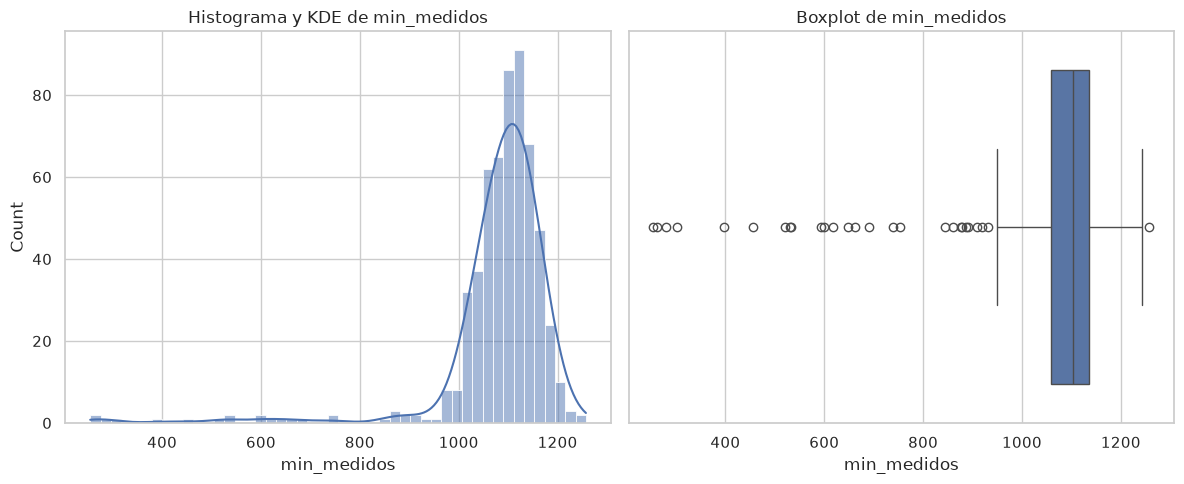

count     570.0
mean     1081.0
std       117.0
min       255.0
25%      1059.0
50%      1103.0
75%      1135.0
max      1257.0
Name: min_medidos, dtype: float64


In [6]:
plot_combined_graphs(crudo, ["min_medidos"])
print(crudo["min_medidos"].describe().round(0))

La mayoría de días está bien medida (la mediana ronda los 1.100 minutos), pero hay una cola de días con muchos huecos. Se fija un criterio sencillo: **un día cuenta si el collar midió al menos medio día (720 minutos)**.

In [7]:
MIN_MEDIDOS = 720

descartados = crudo[crudo["min_medidos"] < MIN_MEDIDOS]
print(f"Días descartados: {len(descartados)} de {len(crudo)} ({100 * len(descartados) / len(crudo):.1f} %)\n")
print(descartados[["perro", "fecha", "min_medidos"]].sort_values("min_medidos"))

df = crudo[crudo["min_medidos"] >= MIN_MEDIDOS].copy()

Días descartados: 15 de 570 (2.6 %)

      perro      fecha  min_medidos
0    cherry 2026-02-22   254.550000
697    plum 2026-02-22   261.283333
200    coco 2026-03-26   280.150000
722    plum 2026-03-19   301.466667
777    plum 2026-05-13   396.283333
723    plum 2026-03-20   455.433333
334    coco 2026-08-07   521.233333
843    plum 2026-07-18   531.650000
108  cherry 2026-06-10   533.066667
249    coco 2026-05-14   592.916667
23   cherry 2026-03-17   600.366667
271    coco 2026-06-05   617.400000
894    plum 2026-09-07   647.783333
704    plum 2026-03-01   662.433333
793    plum 2026-05-29   690.050000


Se descartan 15 días, un 2,6 %. Entre ellos están el primer día de cada perro, en el que el collar solo midió unas horas, y el día con nulos de plum.

### 3.4 De minutos a porcentaje del tiempo medido

Las columnas `min_*` reparten los 1.440 minutos del día, así que un día con muchas horas sin datos tendrá a la fuerza menos minutos de reposo. Para comparar días y perros se usa el **porcentaje del tiempo realmente medido**.

In [8]:
df["pct_reposo"] = 100 * df["min_reposo"] / df["min_medidos"]
df["pct_calma"] = 100 * df["min_calma"] / df["min_medidos"]
df["pct_activo"] = 100 * df["min_activo"] / df["min_medidos"]
df["pct_intenso"] = 100 * df["min_intenso"] / df["min_medidos"]

cherry = df[df["perro"] == "cherry"]
print("Correlación con los minutos sin datos (cherry):")
print("  minutos de reposo:   ", round(cherry["min_reposo"].corr(cherry["min_sin_datos"]), 2))
print("  porcentaje de reposo:", round(cherry["pct_reposo"].corr(cherry["min_sin_datos"]), 2))

Correlación con los minutos sin datos (cherry):
  minutos de reposo:    -0.94
  porcentaje de reposo: -0.62


El porcentaje reduce la dependencia del tiempo sin datos (de −0,94 a −0,62), aunque **no la elimina del todo**. Aun así, es la forma más justa de comparar días con distinto tiempo medido.

### 3.5 Ventana común

Para comparar a los perros en las mismas fechas y que las tres clases queden equilibradas, se usan solo los días en los que los tres tienen datos:

In [9]:
VENTANA_INICIO = "2026-03-26"   # primer día con datos de los tres perros
VENTANA_FIN = "2026-09-09"      # último día con datos de los tres perros

datos = df[(df["fecha"] >= VENTANA_INICIO) & (df["fecha"] <= VENTANA_FIN)].copy()

print("Días que quedan fuera de la ventana:")
print(df[(df["fecha"] < VENTANA_INICIO) | (df["fecha"] > VENTANA_FIN)]["perro"].value_counts())
print("\nDías por perro en la ventana:")
print(datos["perro"].value_counts())
print("\nValores nulos:", datos.isna().sum().sum())

Días que quedan fuera de la ventana:
perro
cherry    30
plum      29
coco       1
Name: count, dtype: int64

Días por perro en la ventana:
perro
cherry    167
coco      164
plum      164
Name: count, dtype: int64

Valores nulos: 0


Quedan 495 días, repartidos de forma equilibrada entre los tres perros y sin valores nulos.

## Paso 4: División en train y test

Los datos se ordenan por fecha y se cortan el 1 de agosto: lo anterior es train, y agosto y septiembre son test. No se usa una división aleatoria porque:

- **El modelo se usaría con días futuros**, así que se prueba igual: aprende del pasado y se evalúa con días posteriores.
- **Los días seguidos de un mismo perro se parecen.** Con una división aleatoria, el test tendría días casi idénticos a otros de train y el resultado saldría mejor de lo que es.

El test cae a finales de verano. Si el comportamiento cambia con la época del año (H2), el resultado en test podría bajar algo por eso.

In [10]:
datos = datos.sort_values(["fecha", "perro"]).reset_index(drop=True)

CORTE = "2026-08-01"
train_set = datos[datos["fecha"] < CORTE]
test_set = datos[datos["fecha"] >= CORTE]

print(f"train: {len(train_set)} días, del {train_set['fecha'].min().date()} al {train_set['fecha'].max().date()}")
print(f"test:  {len(test_set)} días, del {test_set['fecha'].min().date()} al {test_set['fecha'].max().date()}")
print(f"proporción de test: {100 * len(test_set) / len(datos):.1f} %")
pd.DataFrame({"train": train_set["perro"].value_counts(), "test": test_set["perro"].value_counts()})

train: 377 días, del 2026-03-26 al 2026-07-31
test:  118 días, del 2026-08-01 al 2026-09-09
proporción de test: 23.8 %


,train,test
perro,,
cherry,127,40
coco,125,39
plum,125,39


El corte deja 377 días de train y 118 de test (un 23,8 %), con los tres perros equilibrados en ambos.

**A partir de aquí, todo el EDA y todas las decisiones del modelo se hacen solo con train.** Los datasets de ladridos por franja y de actividad por hora se cruzan con los días de train cuando se usan.

## Paso 5: Análisis univariante

Todo el EDA usa solo `train_set`. Antes de analizar conviene priorizar las variables:

| Papel | Columnas |
|---|---|
| **Señales de comportamiento** | `pct_reposo`, `pct_calma`, `pct_activo`, `pct_intenso`, `ladridos_total`, `fc_media`, `fr_media` |
| Variantes de las anteriores | `fc_min`, `fc_max`, `fr_min`, `fr_max`, `ladridos_franjas`, `ladridos_max_30min` |
| Contexto | `fecha`, `es_finde`, `mes`, `temp_disp_media` |

⚠️ `train_set` mezcla a los tres perros, así que aquí se buscan sobre todo **problemas en los datos**. La comparación entre perros llega en el bivariante.

In [11]:
SENALES = ["pct_reposo", "pct_calma", "pct_activo", "pct_intenso", "ladridos_total", "fc_media", "fr_media"]
VARIANTES = ["fc_min", "fc_max", "fr_min", "fr_max", "ladridos_franjas", "ladridos_max_30min"]
CANDIDATAS = SENALES + VARIANTES

### 5.1 Target y variables categóricas

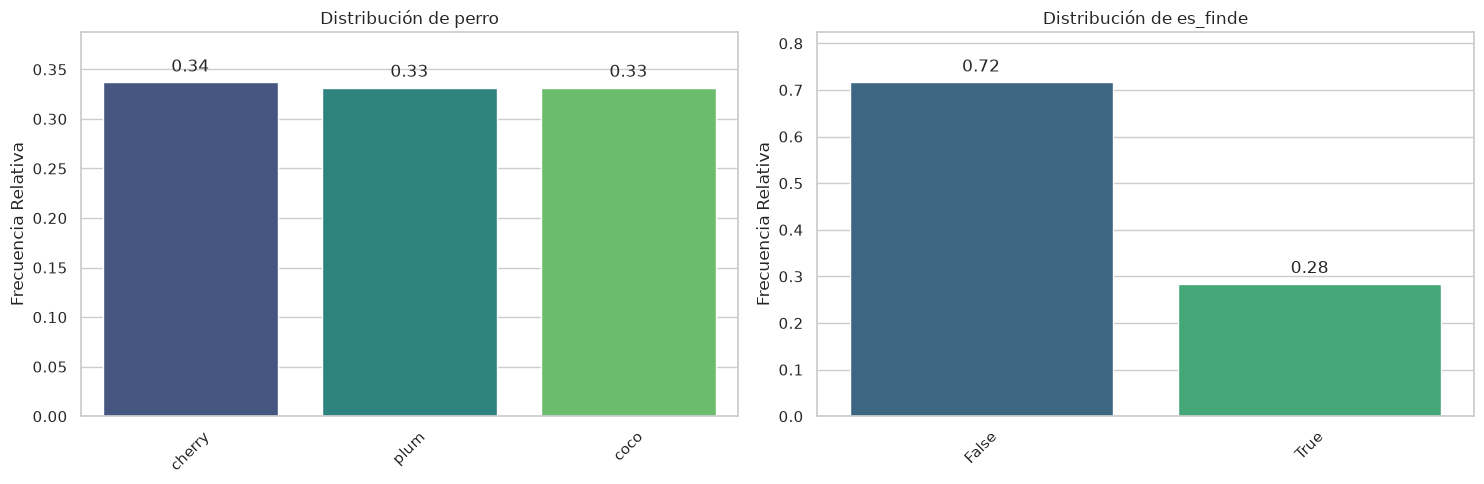

In [12]:
pinta_distribucion_categoricas(train_set, ["perro", "es_finde"], relativa=True, mostrar_valores=True)

Las tres clases están equilibradas, con un tercio de los días cada una, así que **no hace falta ninguna técnica de balanceo**. Algo más de una cuarta parte de los días son fin de semana, lo esperable (2 de cada 7).

### 5.2 Tendencia central y dispersión

In [13]:
resumen = train_set[SENALES].describe().T
resumen["media - mediana"] = resumen["mean"] - resumen["50%"]
resumen.round(2)

,count,mean,std,min,25%,50%,75%,max,media - mediana
pct_reposo,377.0,85.58,3.07,68.30,83.90,85.75,87.54,92.64,-0.17
pct_calma,377.0,3.95,1.11,1.36,3.05,3.91,4.71,6.82,0.03
pct_activo,377.0,10.14,2.18,2.81,8.55,10.11,11.53,17.79,0.03
pct_intenso,377.0,0.26,1.53,0.00,0.00,0.00,0.00,12.62,0.26
ladridos_total,377.0,133.51,156.65,0.00,9.00,83.00,207.00,1054.00,50.51
fc_media,377.0,61.59,4.59,53.78,58.31,60.48,64.32,83.42,1.12
fr_media,377.0,10.16,1.98,6.42,8.81,9.69,11.50,17.84,0.47


- En `ladridos_total` la media (133,51) supera con mucho a la mediana (83): unos pocos días con muchísimos ladridos tiran de la media hacia arriba.
- En `fc_media` y `fr_media` la media supera algo a la mediana (1,12 y 0,47), y en `pct_intenso` la mediana es 0.
- En los demás porcentajes de actividad, media y mediana casi coinciden.

### 5.3 Distribuciones

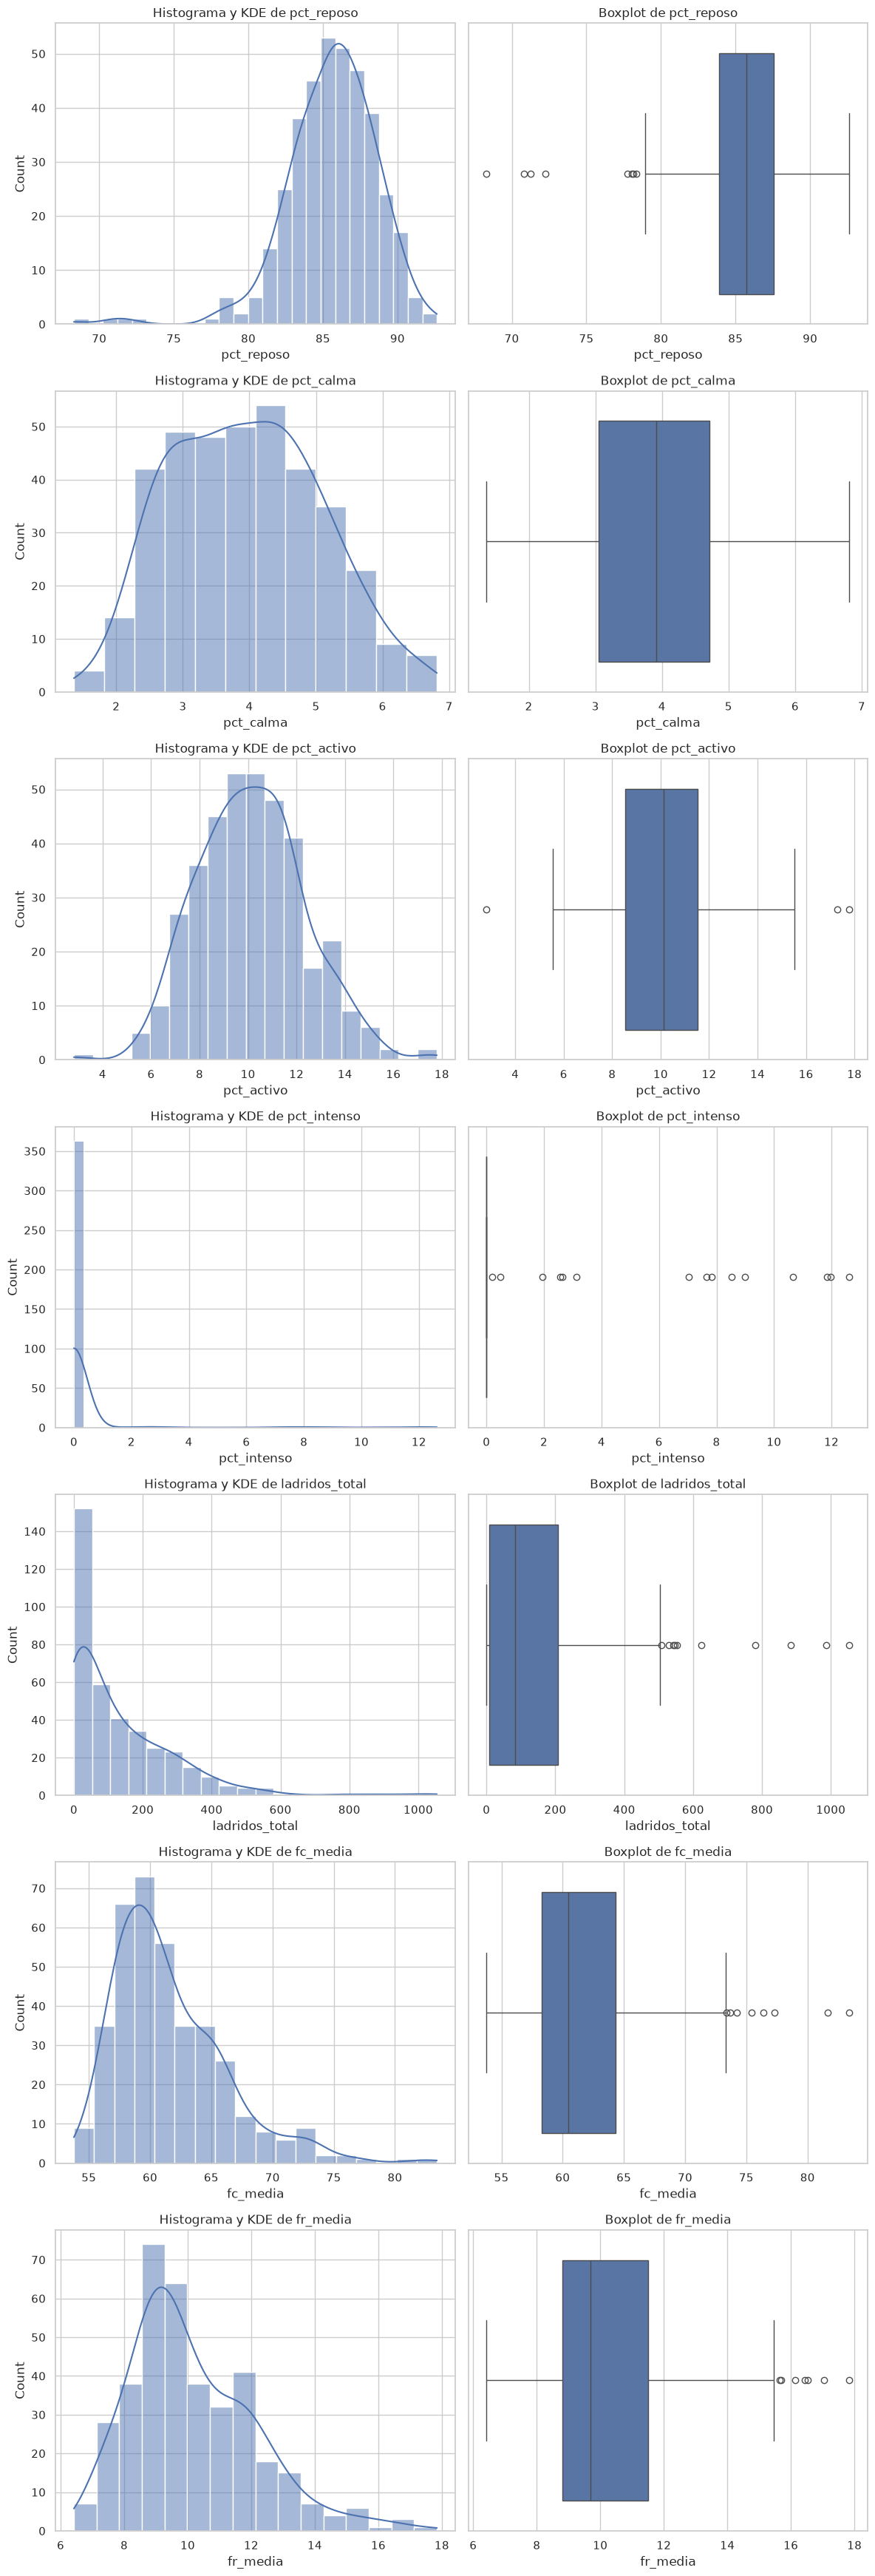

In [14]:
plot_combined_graphs(train_set, SENALES)

- `ladridos_total` tiene una cola larga hacia la derecha y un pico junto a cero.
- `pct_intenso` es casi una única barra en cero.
- `fc_media` y `fr_media` tienen cola hacia valores altos, y `pct_reposo`, unos pocos días con mucho menos reposo de lo habitual.
- `pct_calma` tiene una joroba ancha y achatada, una pista de que puede mezclar grupos distintos.
- `pct_activo` tiene una sola joroba, pero eso **no significa que los tres perros sean iguales**: se comprueba en el bivariante.

### 5.4 Variables casi constantes

In [15]:
print("Días con pct_intenso = 0:", (train_set["pct_intenso"] == 0).sum(), "de", len(train_set))
print("Días con algo de actividad intensa, por perro:")
print(train_set[train_set["pct_intenso"] > 0]["perro"].value_counts())

print("\nValores que toma fc_min y número de días con cada uno:")
print(train_set["fc_min"].value_counts().sort_index())
print("\n% de días en que fc_min vale 51:")
print(train_set.groupby("perro")["fc_min"].apply(lambda valores: round(100 * (valores == 51).mean())))

Días con pct_intenso = 0: 362 de 377
Días con algo de actividad intensa, por perro:
perro
plum      6
cherry    6
coco      3
Name: count, dtype: int64

Valores que toma fc_min y número de días con cada uno:
fc_min
42.0     54
44.0     12
46.0      8
48.0      2
50.0      7
51.0    255
52.0     27
53.0      9
54.0      3
Name: count, dtype: int64

% de días en que fc_min vale 51:
perro
cherry    74
coco      59
plum      70
Name: fc_min, dtype: int64


- `pct_intenso` es cero en 362 de 377 días, y los días restantes se reparten entre los tres perros, con entre 3 y 6 cada uno. No sirve para compararlos.
- `fc_min` solo toma unos pocos valores, y vale 51 entre el 59 % y el 74 % de los días en los tres perros. Como casi siempre marca lo mismo, aporta muy poca información.

### 5.5 Valores extremos

Se buscan dentro de cada perro, con la regla de 1,5 veces el rango intercuartílico: si los perros tienen niveles distintos, lo normal en uno parecería extremo en otro.

In [16]:
extremos = {}
for perro in PERROS:
    datos_perro = train_set[train_set["perro"] == perro][CANDIDATAS]
    q1 = datos_perro.quantile(0.25)
    q3 = datos_perro.quantile(0.75)
    rango = q3 - q1
    extremos[perro] = ((datos_perro < q1 - 1.5 * rango) | (datos_perro > q3 + 1.5 * rango)).sum()
pd.DataFrame(extremos)

,cherry,coco,plum
pct_reposo,2,4,2
pct_calma,1,2,0
pct_activo,1,1,0
pct_intenso,6,3,6
ladridos_total,5,2,15
fc_media,5,2,2
fr_media,2,2,5
fc_min,33,51,38
fc_max,0,3,13
fr_min,0,1,4


La mayoría de variables tienen pocos valores extremos, con dos casos que destacan:

- **`fc_min` acumula muchos**, entre 33 y 51 por perro, porque casi siempre marca 51 (5.4) y cualquier otro valor sale como extremo. En `pct_intenso` pasa lo mismo: sus extremos son justo los pocos días con algo de actividad intensa.
- **Plum tiene más extremos que los otros dos** en `ladridos_total` (15) y en `fc_max` (13).

¿Son errores de medida?

In [17]:
fuera_de_rango = train_set[(train_set["fc_media"] > 140) | (train_set["fr_media"] > 35)]
print("Días con FC media > 140 o FR media > 35:", len(fuera_de_rango))

print("\nMáximos puntuales de cada día:")
print(train_set[["fc_max", "fr_max"]].describe().round(1))

print("\nLos 5 días con la FR media más alta:")
print(train_set.nlargest(5, "fr_media")[["perro", "fecha", "fr_media"]])

Días con FC media > 140 o FR media > 35: 0

Máximos puntuales de cada día:
       fc_max  fr_max
count   377.0   377.0
mean     97.9    25.7
std      24.9     9.1
min      60.0    10.0
25%      80.0    19.0
50%      92.0    24.0
75%     107.0    32.0
max     180.0    70.0

Los 5 días con la FR media más alta:
      perro      fecha   fr_media
350  cherry 2026-07-23  17.841584
365  cherry 2026-07-28  17.037559
374  cherry 2026-07-31  16.526178
352    plum 2026-07-23  16.438679
353  cherry 2026-07-24  16.142857


Ninguna media diaria supera los valores orientativos de un perro adulto en reposo (FC de hasta 140 lpm y FR de hasta 35 rpm). Hay picos puntuales altos (`fc_max` llega a 180 lpm), pero son momentos aislados, no medias del día. Y las cinco FR medias más altas son de finales de julio, en pleno verano, lo que encaja con el calor más que con errores de medida.

**No se elimina ningún dato por ser extremo.**

### 5.6 ¿Sobra alguna variante?

Si una variable está casi perfectamente correlacionada con otra, no aporta información nueva.

In [18]:
pares = [("ladridos_total", "ladridos_max_30min"), ("ladridos_total", "ladridos_franjas"),
         ("fr_media", "fr_max"), ("fr_media", "fr_min"),
         ("fc_media", "fc_min"), ("fc_media", "fc_max"),
         ("pct_reposo", "pct_activo")]
for variable_1, variable_2 in pares:
    print(f"{variable_1} vs {variable_2}: r = {train_set[variable_1].corr(train_set[variable_2]):.2f}")

ladridos_total vs ladridos_max_30min: r = 0.89
ladridos_total vs ladridos_franjas: r = 0.70
fr_media vs fr_max: r = 0.61
fr_media vs fr_min: r = 0.62
fc_media vs fc_min: r = 0.02
fc_media vs fc_max: r = 0.20
pct_reposo vs pct_activo: r = -0.79


| Variable | r | Decisión |
|---|---|---|
| `ladridos_max_30min` | 0,89 con el total | **Fuera**: repite casi la misma información que `ladridos_total` |
| `ladridos_franjas` | 0,70 con el total | Se queda: mide cómo se reparten los ladridos en el día |
| `fr_max`, `fr_min` | 0,61 y 0,62 con la media | Se quedan |
| `fc_max`, `fc_min` | 0,20 y 0,02 con la media | Información distinta de la media (aunque `fc_min` es casi constante, 5.4) |
| `pct_reposo` | −0,79 con `pct_activo` | Los porcentajes reparten el mismo tiempo medido: no conviene usarlos todos a la vez |

### 5.7 Conclusiones del univariante

1. **Las clases están equilibradas:** no hace falta balanceo.
2. **No hay valores imposibles.** Los extremos tienen explicación y no se elimina ningún dato.
3. **`pct_intenso` y `fc_min` casi nunca cambian**, y **`ladridos_max_30min` repite `ladridos_total`**: las tres son candidatas a descartar.
4. **`ladridos_total` tiene un pico junto a cero y `pct_calma` una joroba ancha.** Hay que ver si se deben a perros concretos.

## Paso 6: Análisis bivariante — ¿qué distingue a cada perro?

Primero se compara cada candidata entre perros. Después se contrastan las hipótesis, con un gráfico y un test en cada una.

### 6.1 Candidatas por perro

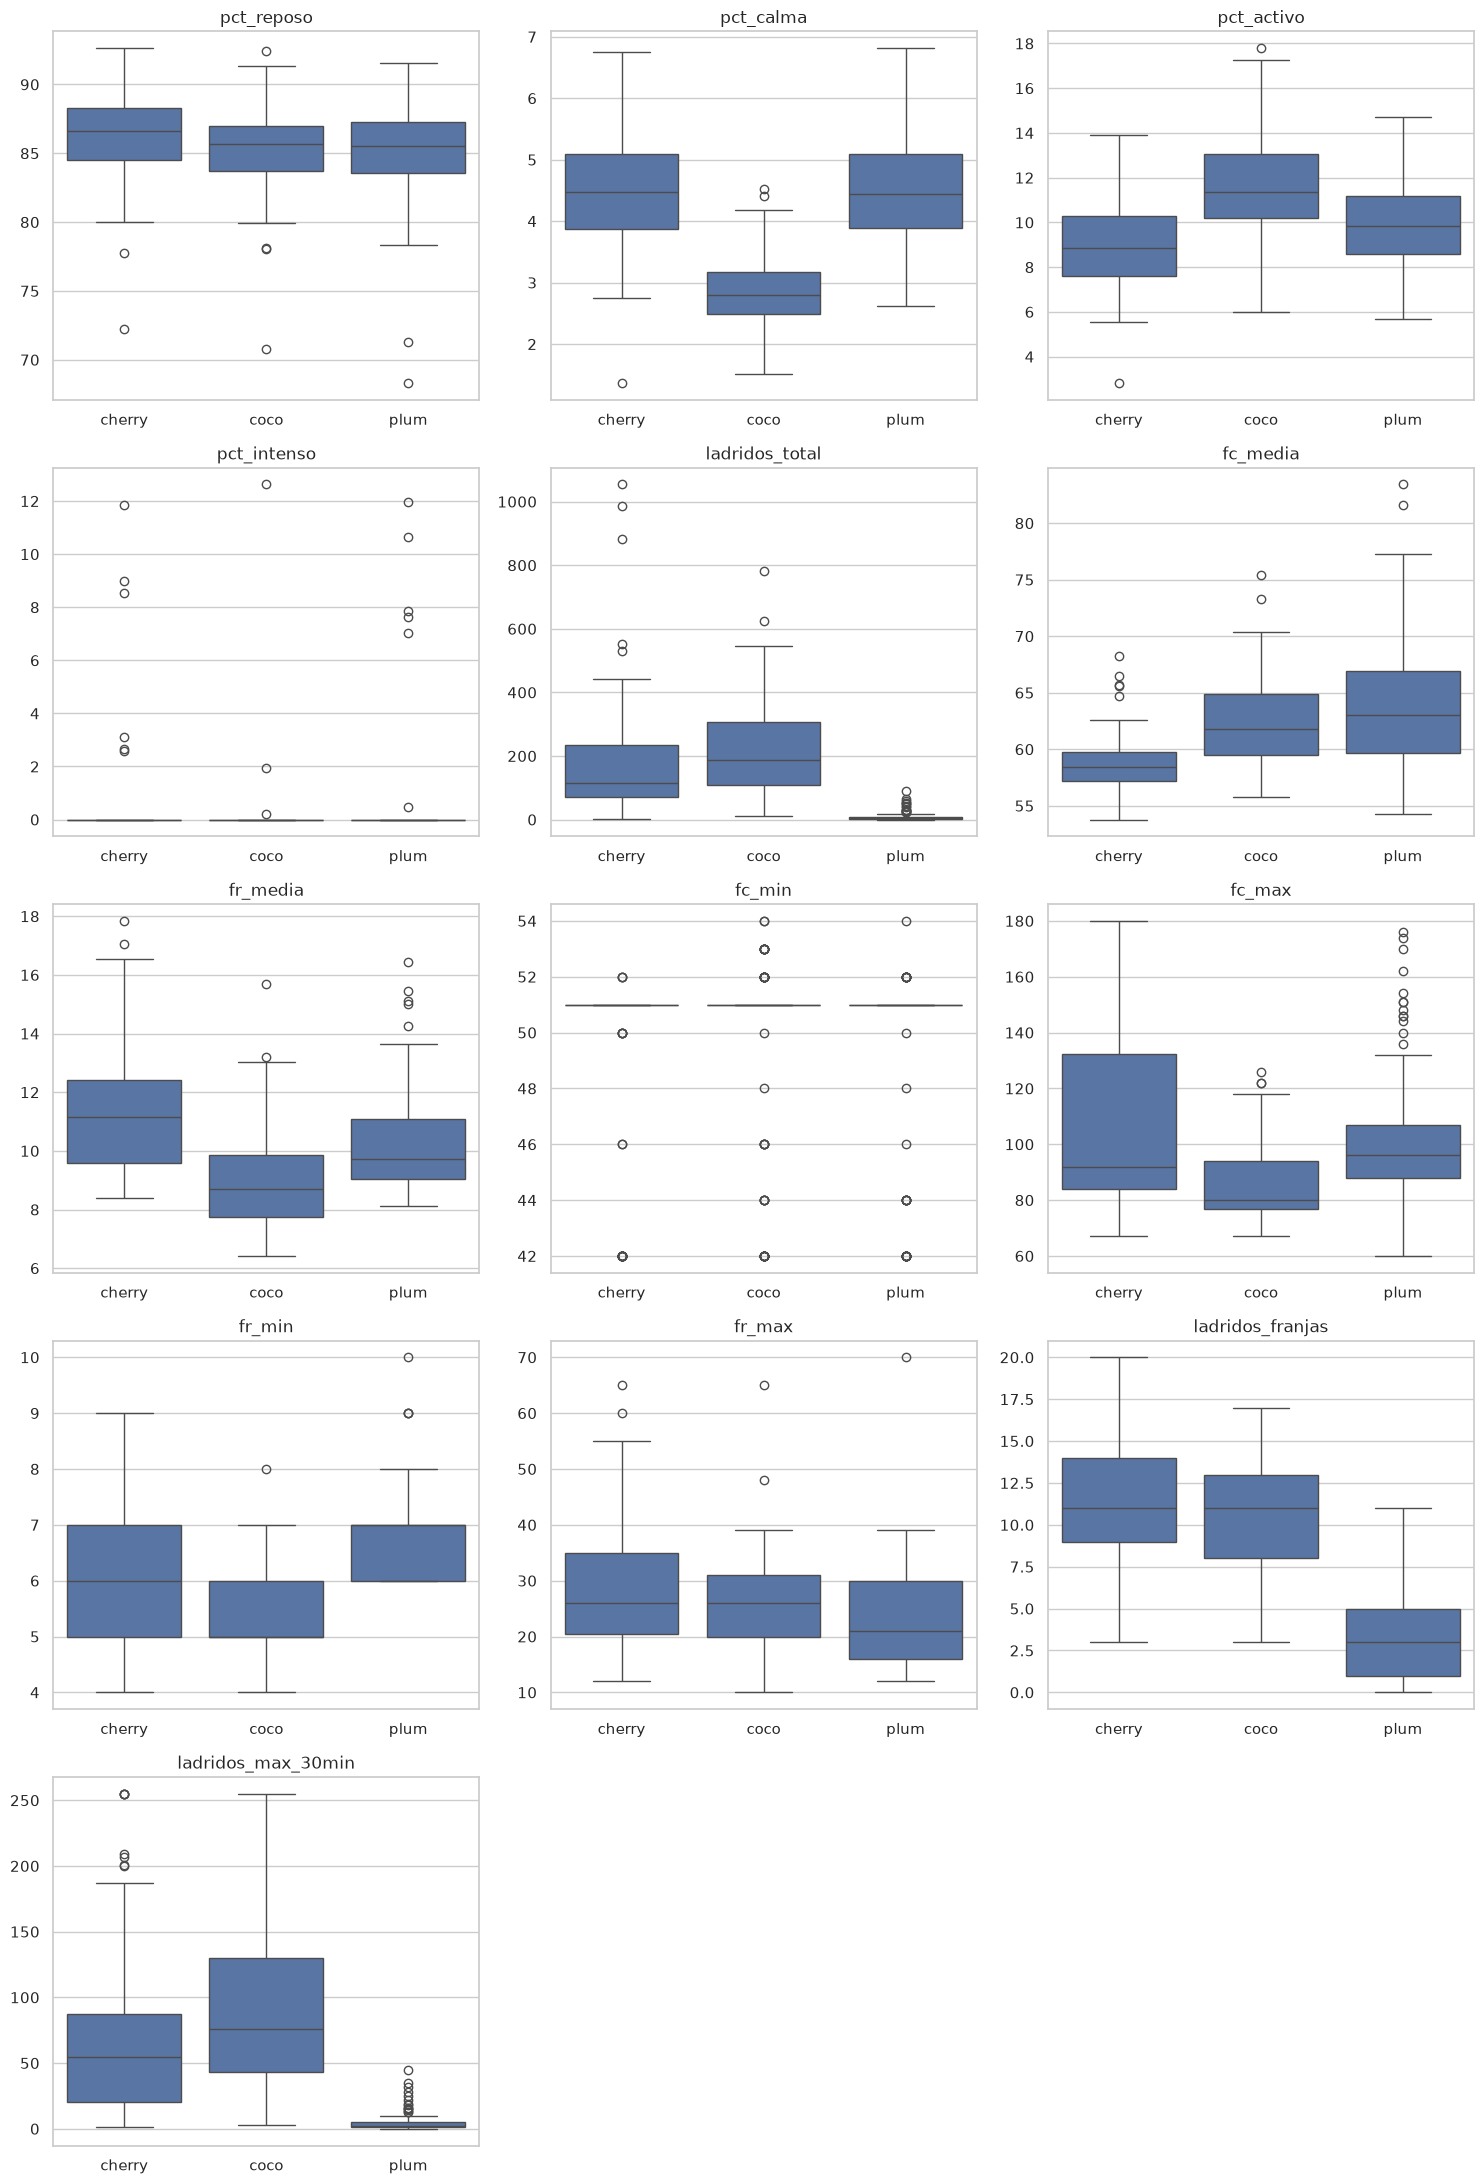

perro,cherry,coco,plum
pct_reposo,86.6,85.7,85.5
pct_calma,4.5,2.8,4.4
pct_activo,8.9,11.4,9.9
pct_intenso,0.0,0.0,0.0
ladridos_total,115.0,187.0,4.0
fc_media,58.4,61.8,63.0
fr_media,11.2,8.7,9.7
fc_min,51.0,51.0,51.0
fc_max,92.0,80.0,96.0
fr_min,6.0,5.0,7.0


In [19]:
fig, axes = plt.subplots(5, 3, figsize=(15, 22))
axes = axes.flatten()
for i, variable in enumerate(CANDIDATAS):
    sns.boxplot(data=train_set, x="perro", y=variable, order=PERROS, ax=axes[i])
    axes[i].set_title(variable)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
for j in range(len(CANDIDATAS), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("src/img/paso6_candidatas_por_perro.png", dpi=120)
plt.show()

train_set.groupby("perro")[CANDIDATAS].median().round(1).T

- **Los ladridos son la señal más clara:** plum ladra muy poco, con una mediana de 4 ladridos al día frente a 115 de cherry y 187 de coco. El pico junto a cero del univariante es plum.
- **La frecuencia cardíaca media** ordena a los tres perros (58,4, 61,8 y 63,0 lpm) y **la respiratoria** distingue sobre todo a cherry (11,2 frente a 8,7 y 9,7).
- **En actividad destaca coco:** más tiempo activo (11,4 % frente a 8,9 % y 9,9 %) y menos en calma (2,8 % frente a 4,5 % y 4,4 %). La joroba ancha de `pct_calma` en el univariante es coco.
- `pct_reposo` apenas cambia entre perros (86,6, 85,7 y 85,5 %).

### 6.2 ¿Qué test usar?

Para comparar dos grupos, el t-Student solo es adecuado si los datos de cada grupo tienen forma de campana de Gauss. Se comprueba con los histogramas por perro:

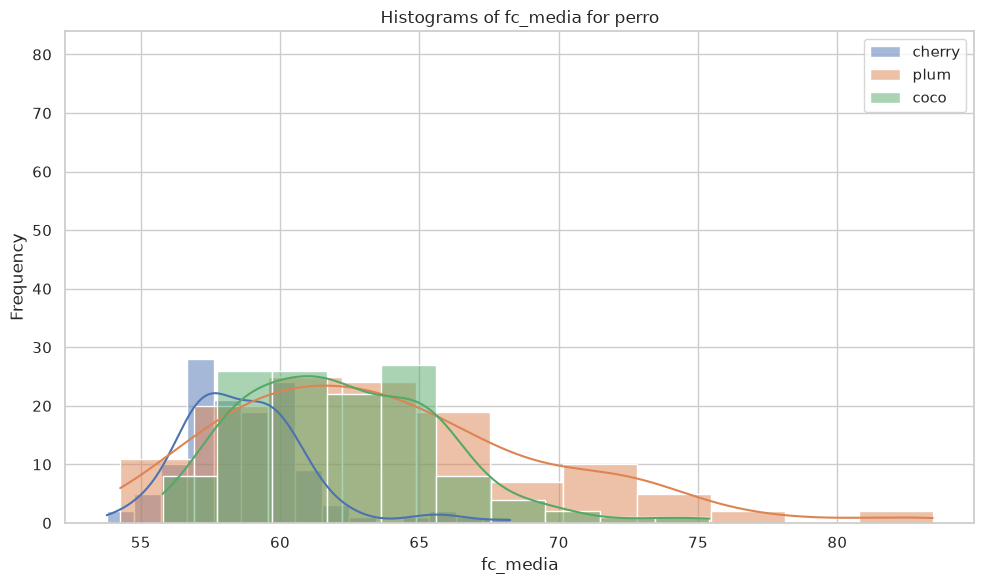

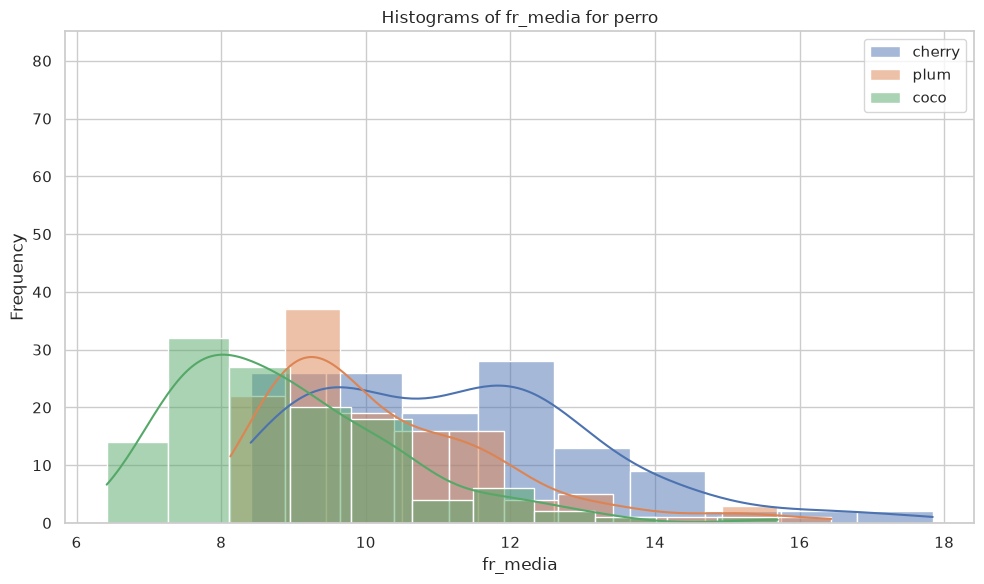

In [20]:
plot_grouped_histograms(train_set, "perro", "fc_media", group_size=3)
plot_grouped_histograms(train_set, "perro", "fr_media", group_size=3)

Las distribuciones no son simétricas en todos los perros y tienen colas hacia valores altos, así que no se cumple la condición del t-Student. La U de Mann-Whitney no necesita esa forma, así que se usa en **todas** las comparaciones de dos grupos.

| Comparación | Test |
|---|---|
| Dos grupos (dos perros, o laborable frente a fin de semana) | **U de Mann-Whitney** |
| Los tres perros a la vez | **ANOVA**, y después Mann-Whitney por pares para ver qué perro se distingue de cuál |
| Dos variables numéricas | **Correlación de Pearson** |
| Dos variables categóricas | **Chi-cuadrado** |

### 6.3 H1 — Huella fisiológica

**Hipótesis:** la frecuencia cardíaca y respiratoria en reposo difieren entre los perros. En 6.1 las cajas de `fc_media` y `fr_media` se separan, aunque se solapan.

**ANOVA.** Hipótesis nula: la media es la misma en los tres perros.

In [21]:
for senal in ["fc_media", "fr_media"]:
    grupos = [train_set[train_set["perro"] == perro][senal] for perro in PERROS]
    resultado = stats.f_oneway(*grupos)
    print(f"{senal}: F = {resultado.statistic:.1f}, p = {resultado.pvalue:.2e}")

fc_media: F = 51.2, p = 2.30e-20
fr_media: F = 57.5, p = 1.72e-22


**U de Mann-Whitney por pares**, porque ANOVA solo dice que hay *alguna* diferencia y hace falta saber qué perro se distingue de cuál:

In [22]:
PARES_PERROS = [("cherry", "coco"), ("cherry", "plum"), ("coco", "plum")]

filas = []
for senal in ["fc_media", "fr_media"]:
    for perro_1, perro_2 in PARES_PERROS:
        datos_1 = train_set[train_set["perro"] == perro_1][senal]
        datos_2 = train_set[train_set["perro"] == perro_2][senal]
        p = stats.mannwhitneyu(datos_1, datos_2).pvalue
        filas.append({"señal": senal, "par": f"{perro_1} - {perro_2}",
                      "mediana_1": round(datos_1.median(), 1),
                      "mediana_2": round(datos_2.median(), 1),
                      "p_valor": p, "significativo": p < 0.05})
tabla_h1 = pd.DataFrame(filas)

print("Comparaciones significativas:", tabla_h1["significativo"].sum(), "de", len(tabla_h1))
print("p-valor más alto:", round(tabla_h1["p_valor"].max(), 2))
tabla_h1

Comparaciones significativas: 5 de 6
p-valor más alto: 0.09


,señal,par,mediana_1,mediana_2,p_valor,significativo
0,fc_media,cherry - coco,58.4,61.8,2.852533e-17,True
1,fc_media,cherry - plum,58.4,63.0,3.994507e-16,True
2,fc_media,coco - plum,61.8,63.0,9.057570e-02,False
3,fr_media,cherry - coco,11.2,8.7,4.374551e-20,True
4,fr_media,cherry - plum,11.2,9.7,1.841718e-05,True
5,fr_media,coco - plum,8.7,9.7,5.437293e-12,True


La misma comparación con las señales de actividad y ladridos:

In [23]:
for senal in ["pct_reposo", "pct_calma", "pct_activo", "ladridos_total"]:
    grupos = [train_set[train_set["perro"] == perro][senal] for perro in PERROS]
    print(f"{senal}: p = {stats.f_oneway(*grupos).pvalue:.2e}")

pct_reposo: p = 1.35e-02
pct_calma: p = 2.52e-55
pct_activo: p = 2.48e-22
ladridos_total: p = 8.62e-33


**H1 confirmada en parte.** ANOVA rechaza que los tres perros sean iguales en las dos constantes, y **5 de las 6 comparaciones por pares son significativas**. La FR distingue a cada perro de los otros dos. La FC distingue a cherry de los demás, pero **no a coco de plum** (61,8 frente a 63,0 lpm, p = 0,09).

La actividad y los ladridos también separan a los perros, sobre todo `pct_calma`, `pct_activo` y `ladridos_total`; `pct_reposo` es la que menos.

**Qué implica para el modelo:** la FC y la FR son candidatas principales, pero las cajas se solapan y la FC no separa a coco de plum. El modelo tendrá que combinarlas con la actividad y los ladridos.

### 6.4 H2 — Efecto del calor

**Hipótesis:** en los días más calurosos los perros están menos activos.

Se usa la temperatura del collar (`temp_disp_media`), que sigue las estaciones pero recoge sobre todo el calor del propio perro (`00`, §6). La relación se calcula dentro de cada perro.

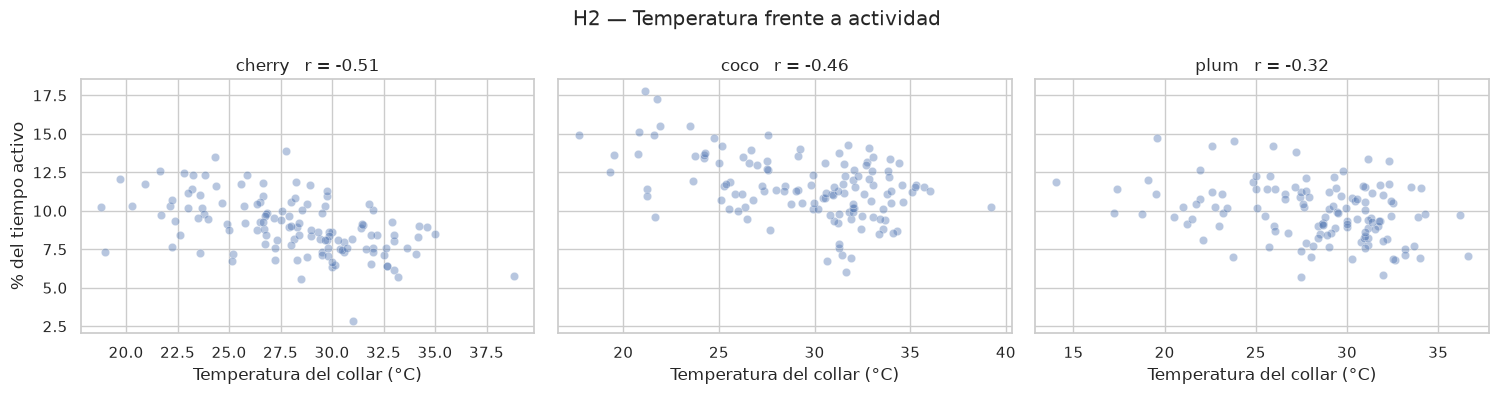

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, perro in enumerate(PERROS):
    datos_perro = train_set[train_set["perro"] == perro]
    r = datos_perro["temp_disp_media"].corr(datos_perro["pct_activo"])
    sns.scatterplot(data=datos_perro, x="temp_disp_media", y="pct_activo", alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{perro}   r = {r:.2f}")
    axes[i].set_xlabel("Temperatura del collar (°C)")
axes[0].set_ylabel("% del tiempo activo")
plt.suptitle("H2 — Temperatura frente a actividad")
plt.tight_layout()
plt.savefig("src/img/paso6_h2_calor.png", dpi=120)
plt.show()

In [25]:
filas = []
for senal in ["pct_activo", "fr_media"]:
    for perro in PERROS:
        datos_perro = train_set[train_set["perro"] == perro]
        r, p = stats.pearsonr(datos_perro["temp_disp_media"], datos_perro[senal])
        filas.append({"señal": senal, "perro": perro, "r": round(r, 2),
                      "p_valor": p, "significativo": p < 0.05})
pd.DataFrame(filas)

,señal,perro,r,p_valor,significativo
0,pct_activo,cherry,-0.51,6.370812e-10,True
1,pct_activo,coco,-0.46,7.426131e-08,True
2,pct_activo,plum,-0.32,2.774268e-04,True
3,fr_media,cherry,0.53,2.231854e-10,True
4,fr_media,coco,0.33,1.718059e-04,True
5,fr_media,plum,0.47,2.726016e-08,True


En los tres perros la actividad **baja** con la temperatura y la frecuencia respiratoria **sube**, siempre de forma significativa.

**¿Calor o época del año?** Con la temperatura cambian otras cosas, como las horas de luz. Si lo que influye es el calor en sí, la relación debería verse también entre días de un mismo verano:

In [26]:
verano = train_set[train_set["mes"] >= 6]   # junio y julio: train acaba el 31 de julio
for senal in ["pct_activo", "fr_media"]:
    for perro in PERROS:
        datos_perro = verano[verano["perro"] == perro]
        r, p = stats.pearsonr(datos_perro["temp_disp_media"], datos_perro[senal])
        print(f"{senal} - {perro}: r = {r:.2f}, p = {p:.3f}")

print("\nDesviación típica de la temperatura: todo train",
      round(train_set["temp_disp_media"].std(), 1), "°C | solo verano",
      round(verano["temp_disp_media"].std(), 1), "°C")

pct_activo - cherry: r = -0.16, p = 0.237
pct_activo - coco: r = 0.13, p = 0.306
pct_activo - plum: r = -0.05, p = 0.693
fr_media - cherry: r = -0.20, p = 0.128
fr_media - coco: r = 0.02, p = 0.860
fr_media - plum: r = 0.15, p = 0.244

Desviación típica de la temperatura: todo train 4.2 °C | solo verano 2.4 °C


**H2 confirmada, con matices.** De marzo a julio, en los días de más temperatura los perros se mueven menos y respiran más rápido. Pero dentro del verano ninguna de las dos relaciones es significativa. Hay dos explicaciones que estos datos no permiten separar: en verano la temperatura varía mucho menos (2,4 °C de desviación típica frente a 4,2), y con poca variación cuesta ver el efecto; o lo que influye es la época del año en conjunto y no el calor de cada día.

**Qué implica para el modelo:** el test cae en agosto y septiembre, en pleno calor, y un modelo que aprende con días de primavera y principios de verano puede fallar más ahí, sobre todo por la FR. Para los avisos, cada día debería compararse con los de la misma época.

### 6.5 H3 — Sincronía de ladridos

**Hipótesis:** los perros que conviven ladran en las mismas franjas de 30 minutos más de lo esperable por azar. Primero se comprueba si ladran lo suficiente como para analizarlos:

In [27]:
fr = franjas.merge(train_set[["perro", "fecha"]], on=["perro", "fecha"])   # solo días de train
fr["ladro"] = fr["ladridos"] > 0

print("% de franjas con algún ladrido:")
print((fr.groupby("perro")["ladro"].mean() * 100).round(1))
print("\nNº de franjas con algún ladrido:")
print(fr.groupby("perro")["ladro"].sum())

% de franjas con algún ladrido:
perro
cherry    23.9
coco      22.0
plum       7.1
Name: ladro, dtype: float64

Nº de franjas con algún ladrido:
perro
cherry    1456
coco      1320
plum       424
Name: ladro, dtype: int64


Plum ladra en pocas franjas, pero sigue teniendo cientos de franjas con ladrido: suficiente para el test.

¿A qué hora ladra cada uno?

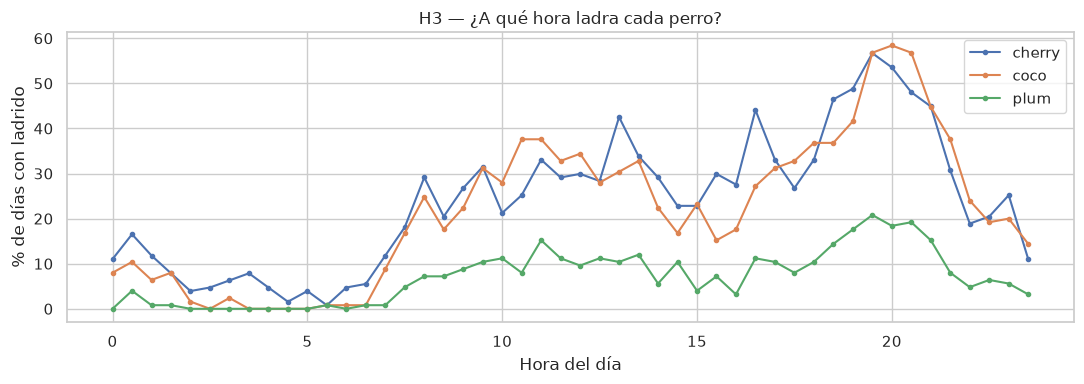

Parecido entre los perfiles horarios (correlación):
        cherry  coco  plum
cherry    1.00  0.93  0.94
coco      0.93  1.00  0.94
plum      0.94  0.94  1.00

Hora a la que empieza la franja con más ladridos (19.5 = 19:30):
cherry    19.5
coco      20.0
plum      19.5
dtype: float64


In [28]:
perfiles_ladridos = {}
fig, ax = plt.subplots(figsize=(11, 4))
for perro in PERROS:
    perfil = fr[fr["perro"] == perro].groupby("franja_30min")["ladro"].mean() * 100
    perfiles_ladridos[perro] = perfil
    ax.plot(perfil.index / 2, perfil.values, marker="o", markersize=3, label=perro)
ax.set_xlabel("Hora del día")
ax.set_ylabel("% de días con ladrido")
ax.set_title("H3 — ¿A qué hora ladra cada perro?")
ax.legend()
plt.tight_layout()
plt.savefig("src/img/paso6_h3_ladridos.png", dpi=120)
plt.show()

perfiles_ladridos = pd.DataFrame(perfiles_ladridos)
print("Parecido entre los perfiles horarios (correlación):")
print(perfiles_ladridos.corr().round(2))
print("\nHora a la que empieza la franja con más ladridos (19.5 = 19:30):")
print(perfiles_ladridos.idxmax() / 2)

Los tres ladran sobre todo por la tarde, con el pico entre las 19:30 y las 20:30, y sus perfiles se parecen mucho. **Cuidado:** si ladran a las mismas horas, coincidirán aunque no se estén respondiendo entre sí.

**Chi-cuadrado.** Para cada par de perros se juntan las franjas del mismo día y hora y se cruza "ladró / no ladró":

In [29]:
def franjas_de(datos, perro):
    return datos[datos["perro"] == perro][["fecha", "franja_30min", "ladro"]].rename(columns={"ladro": perro})


def test_sincronia(datos, perro_1, perro_2):
    juntos = franjas_de(datos, perro_1).merge(franjas_de(datos, perro_2), on=["fecha", "franja_30min"])
    contingencia = pd.crosstab(juntos[perro_1], juntos[perro_2])
    chi2, p, grados_libertad, esperadas = stats.chi2_contingency(contingencia)
    coinciden = contingencia.loc[True, True]
    return {"par": f"{perro_1} - {perro_2}", "franjas": len(juntos),
            "ladran_a_la_vez": coinciden,
            "esperado_por_azar": round(esperadas[1][1], 1),
            "veces_lo_esperado": round(coinciden / esperadas[1][1], 2),
            "p_valor": p}


pd.DataFrame([test_sincronia(fr, perro_1, perro_2) for perro_1, perro_2 in PARES_PERROS])

,par,franjas,ladran_a_la_vez,esperado_por_azar,veces_lo_esperado,p_valor
0,cherry - coco,5952,757,311.9,2.43,6.522891e-234
1,cherry - plum,5952,272,101.3,2.69,4.535084e-90
2,coco - plum,5856,308,90.7,3.39,1.592138e-157


Coinciden entre 2,43 y 3,39 veces más de lo esperable por azar. Pero parte de eso puede deberse solo a que ladran a las mismas horas. Para comprobarlo, se repite el test **solo en horas punta, de 18:00 a 22:00**, cuando los tres ladran mucho y la hora del día pesa menos:

In [30]:
punta = fr[(fr["franja_30min"] >= 36) & (fr["franja_30min"] <= 43)]   # franjas 36 a 43 = 18:00 a 22:00
pd.DataFrame([test_sincronia(punta, perro_1, perro_2) for perro_1, perro_2 in PARES_PERROS])

,par,franjas,ladran_a_la_vez,esperado_por_azar,veces_lo_esperado,p_valor
0,cherry - coco,992,292,207.8,1.41,8.768526e-27
1,cherry - plum,992,118,70.5,1.67,1.466388e-16
2,coco - plum,976,132,71.2,1.85,1.767212e-26


**H3 confirmada.** En horas punta la coincidencia baja, pero sigue siendo de 1,41 a 1,85 veces lo esperable y significativa en los tres pares. Es decir, **una parte de la sincronía es rutina compartida**, porque ladran a las mismas horas, **y otra parte es coincidencia en el mismo momento**. Con franjas de 30 minutos no se puede saber si ladran exactamente a la vez ni quién empieza.

**Qué implica para el modelo:** aunque parte de los ladridos responda a la casa, el nivel de cada perro es muy distinto (6.1), así que los ladridos siguen sirviendo para distinguirlos.

### 6.6 H4 — Efecto fin de semana

**Hipótesis:** los perros están más activos en fin de semana. `es_finde` es binaria, así que se usa la U de Mann-Whitney dentro de cada perro.

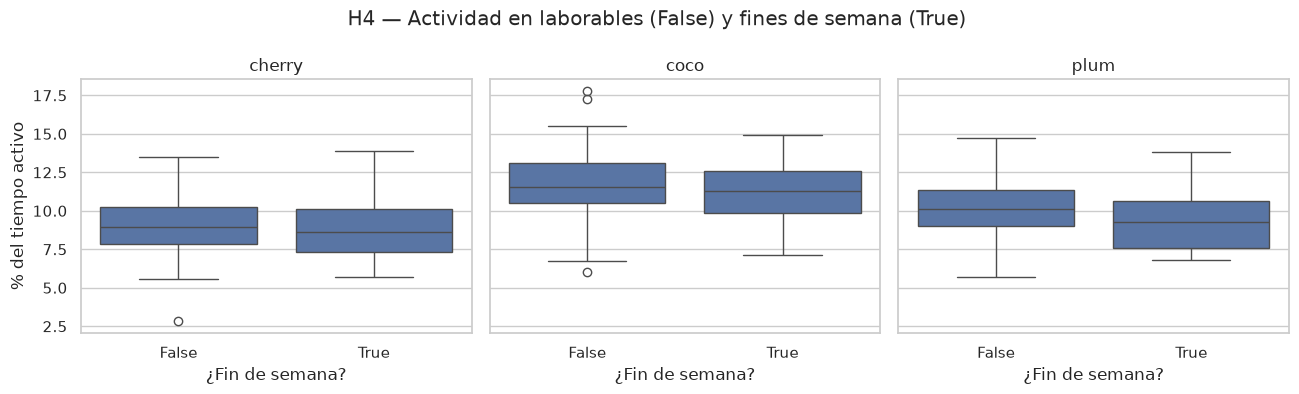

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for i, perro in enumerate(PERROS):
    sns.boxplot(data=train_set[train_set["perro"] == perro], x="es_finde", y="pct_activo", ax=axes[i])
    axes[i].set_title(perro)
    axes[i].set_xlabel("¿Fin de semana?")
axes[0].set_ylabel("% del tiempo activo")
plt.suptitle("H4 — Actividad en laborables (False) y fines de semana (True)")
plt.tight_layout()
plt.savefig("src/img/paso6_h4_finde.png", dpi=120)
plt.show()

In [32]:
filas = []
for perro in PERROS:
    datos_perro = train_set[train_set["perro"] == perro]
    finde = datos_perro[datos_perro["es_finde"]]["pct_activo"]
    laborable = datos_perro[~datos_perro["es_finde"]]["pct_activo"]
    p = stats.mannwhitneyu(finde, laborable).pvalue
    filas.append({"perro": perro, "mediana_finde": round(finde.median(), 1),
                  "mediana_laborable": round(laborable.median(), 1),
                  "diferencia": round(finde.median() - laborable.median(), 1),
                  "p_valor": round(p, 4), "significativo": p < 0.05})
pd.DataFrame(filas)

,perro,mediana_finde,mediana_laborable,diferencia,p_valor,significativo
0,cherry,8.6,9.0,-0.3,0.3158,False
1,coco,11.3,11.5,-0.3,0.2148,False
2,plum,9.3,10.1,-0.8,0.0205,True


**La diferencia va al revés de lo esperado:** los tres perros están algo *menos* activos en fin de semana, aunque solo es significativo en plum. ¿A qué hora se produce esa diferencia?

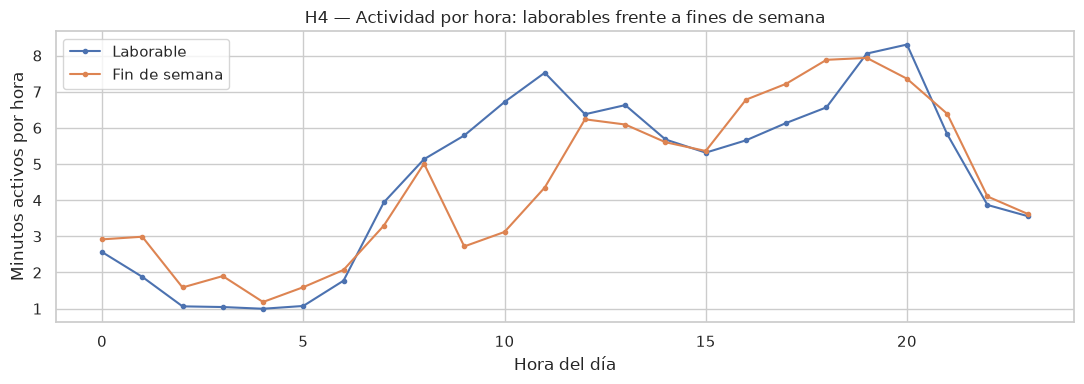

Diferencia fin de semana - laborable (minutos activos por hora), de 6:00 a 13:00:
hora
6     0.3
7    -0.6
8    -0.1
9    -3.1
10   -3.6
11   -3.2
12   -0.1
13   -0.5
Name: min_activo, dtype: float64


In [33]:
h = horaria.merge(train_set[["perro", "fecha", "es_finde"]], on=["perro", "fecha"])
laborables = h[~h["es_finde"]].groupby("hora")["min_activo"].mean()
fines_de_semana = h[h["es_finde"]].groupby("hora")["min_activo"].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(laborables.index, laborables.values, marker="o", markersize=3, label="Laborable")
ax.plot(fines_de_semana.index, fines_de_semana.values, marker="o", markersize=3, label="Fin de semana")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Minutos activos por hora")
ax.set_title("H4 — Actividad por hora: laborables frente a fines de semana")
ax.legend()
plt.tight_layout()
plt.show()

diferencia = (fines_de_semana - laborables).round(1)
print("Diferencia fin de semana - laborable (minutos activos por hora), de 6:00 a 13:00:")
print(diferencia.loc[6:13])

**H4 refutada.** Los perros no están más activos en fin de semana, sino ligeramente menos, y la diferencia se concentra **por la mañana, entre las 9:00 y las 12:00**, con unos 3 minutos activos menos por hora. El resto del día las diferencias son pequeñas y van en los dos sentidos. Qué ocurre en esa franja no se puede saber con estos datos, porque no hay registro de la rutina de la casa.

**Qué implica para el modelo:** ninguna. El calendario es igual para los tres perros cada día, así que no entra como feature. En los avisos tampoco hace falta separar laborables y fines de semana.

## Paso 7: Análisis multivariante

Se miran varias señales a la vez: correlaciones, pairplot y ritmo diario.

### 7.1 Correlaciones con los perros juntos y por separado

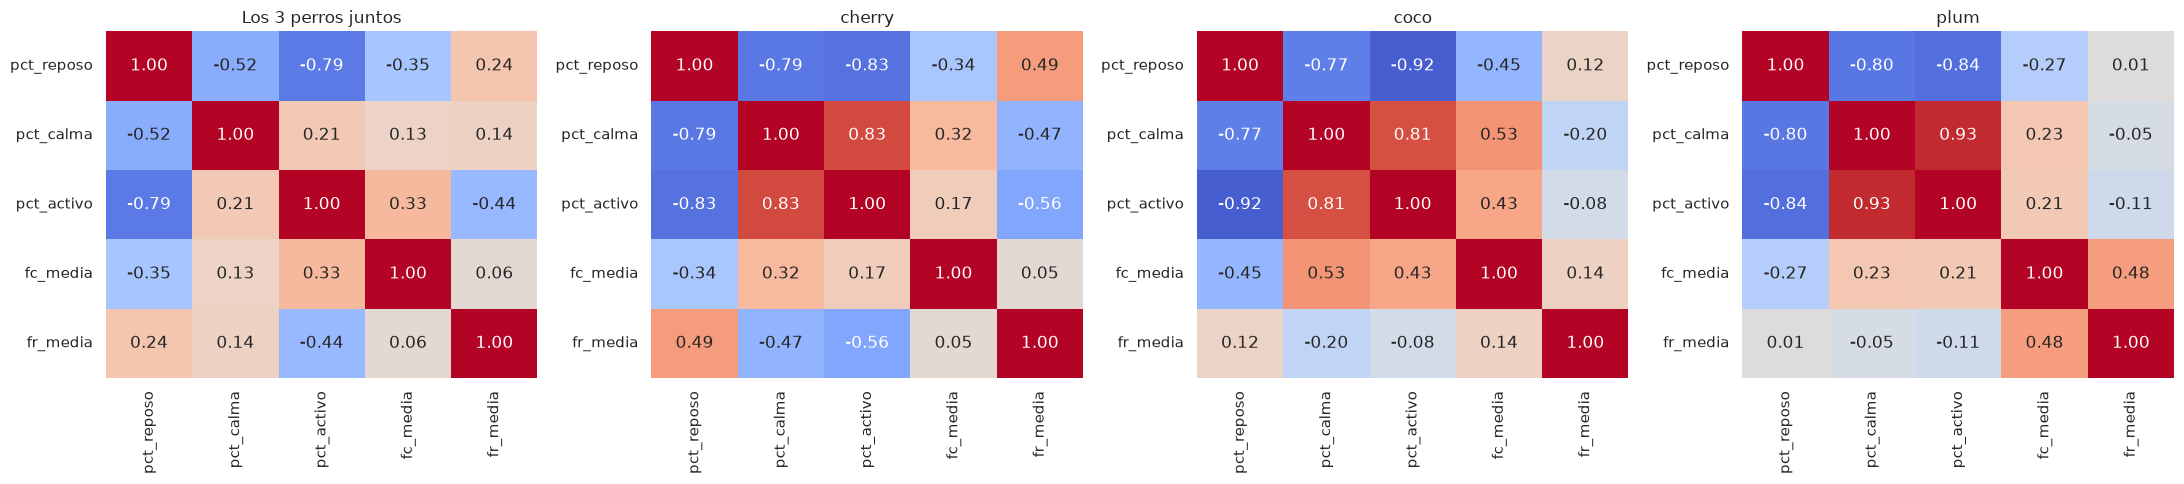

In [34]:
SENALES_MV = ["pct_reposo", "pct_calma", "pct_activo", "fc_media", "fr_media"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.heatmap(train_set[SENALES_MV].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, cbar=False, ax=axes[0])
axes[0].set_title("Los 3 perros juntos")
for i, perro in enumerate(PERROS):
    matriz = train_set[train_set["perro"] == perro][SENALES_MV].corr()
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                cbar=False, ax=axes[i + 1])
    axes[i + 1].set_title(perro)
plt.tight_layout()
plt.savefig("src/img/paso7_correlaciones.png", dpi=120)
plt.show()

In [35]:
for variable_1, variable_2 in [("pct_calma", "fr_media"), ("pct_calma", "pct_activo"), ("fc_media", "fr_media")]:
    print(f"Correlación entre {variable_1} y {variable_2}")
    print("  los 3 juntos:", round(train_set[variable_1].corr(train_set[variable_2]), 2))
    for perro in PERROS:
        datos_perro = train_set[train_set["perro"] == perro]
        print(f"  {perro}:", round(datos_perro[variable_1].corr(datos_perro[variable_2]), 2))

Correlación entre pct_calma y fr_media
  los 3 juntos: 0.14
  cherry: -0.47
  coco: -0.2
  plum: -0.05
Correlación entre pct_calma y pct_activo
  los 3 juntos: 0.21
  cherry: 0.83
  coco: 0.81
  plum: 0.93
Correlación entre fc_media y fr_media
  los 3 juntos: 0.06
  cherry: 0.05
  coco: 0.14
  plum: 0.48


**Al juntar a los perros, algunas relaciones cambian.** Con los tres juntos, más tiempo en calma va con una respiración algo más rápida (+0,14), pero dentro de cada perro ocurre lo contrario: −0,47 en cherry, −0,20 en coco y −0,05 en plum. Al mezclarlos pesa que cherry pasa más tiempo en calma que coco y también respira más rápido (6.1). Con calma y actividad pasa algo parecido: 0,21 con los tres juntos, frente a entre 0,81 y 0,93 dentro de cada perro. Por eso las relaciones se calculan dentro de cada perro.

También se ve que la relación entre FC y FR **no es la misma en todos los perros**: casi nula en cherry (0,05) y coco (0,14), y de 0,48 en plum. Conviene conservar las dos.

### 7.2 ¿Separan mejor las señales combinadas?

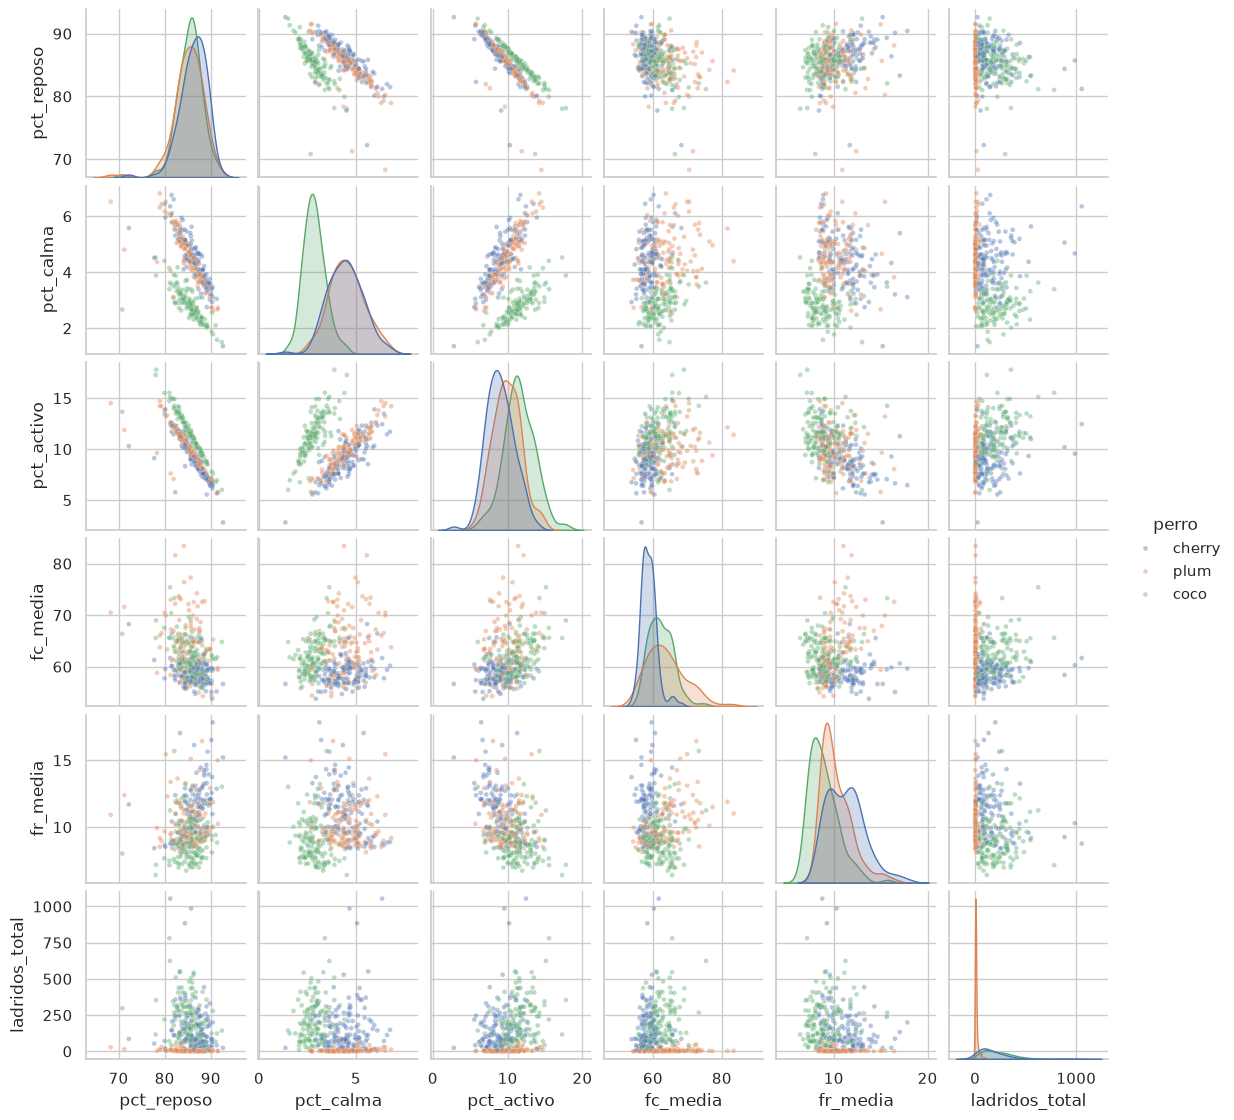

In [36]:
grafico = sns.pairplot(train_set[["perro"] + SENALES_MV + ["ladridos_total"]], hue="perro",
                       plot_kws={"alpha": 0.4, "s": 12}, height=1.9)
grafico.savefig("src/img/paso7_pairplot.png", dpi=120)
plt.show()

En la diagonal, donde cada señal va sola, cada una separa como mucho a un perro de los otros dos: coco en `pct_calma` y plum en `ladridos_total`, mientras que en `pct_reposo` los tres se solapan casi por completo. En los gráficos de dos señales aparecen grupos más reconocibles: al cruzar `pct_calma` con `pct_activo`, coco forma su propia nube, y al cruzar `fc_media` con `fr_media`, cherry (FC baja y FR alta) se separa bastante de plum. **Combinar señales separa mejor a los perros, aunque no del todo.** Medir hasta dónde llega esa separación es trabajo del modelo.

### 7.3 ¿Tiene cada perro su propio horario?

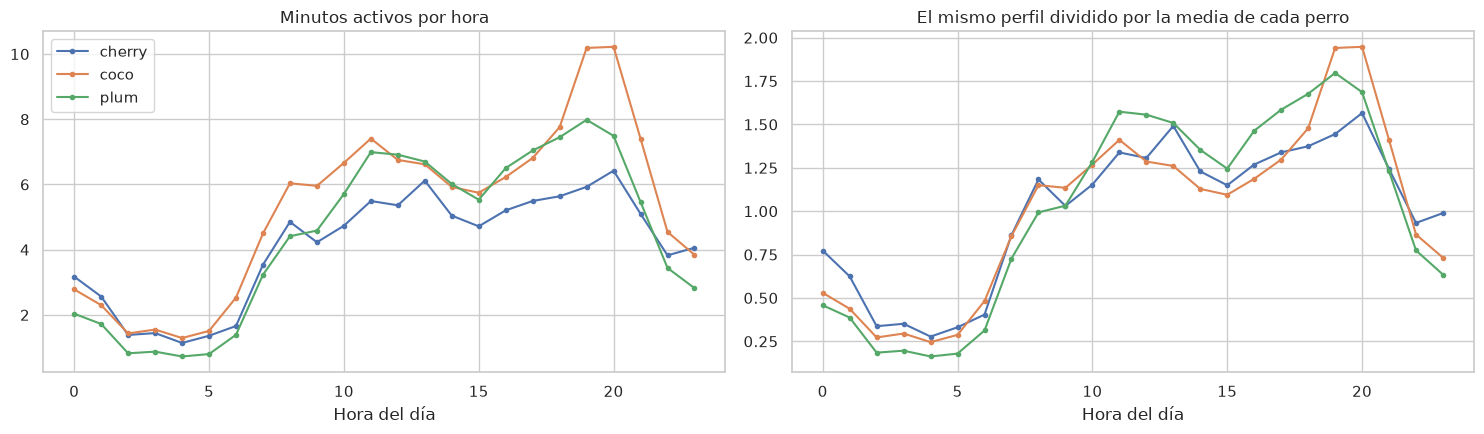

Parecido entre perfiles (correlación):
        cherry  coco  plum
cherry    1.00  0.94  0.97
coco      0.94  1.00  0.95
plum      0.97  0.95  1.00

Hora de máxima actividad de cada perro:
cherry    20
coco      20
plum      19
dtype: int64


In [37]:
hc = horaria.merge(train_set[["perro", "fecha"]], on=["perro", "fecha"])
perfiles = {}
for perro in PERROS:
    perfiles[perro] = hc[hc["perro"] == perro].groupby("hora")["min_activo"].mean()
perfiles = pd.DataFrame(perfiles)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
perfiles.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("Minutos activos por hora")
(perfiles / perfiles.mean()).plot(ax=axes[1], marker="o", markersize=3, legend=False)
axes[1].set_title("El mismo perfil dividido por la media de cada perro")
for ax in axes:
    ax.set_xlabel("Hora del día")
plt.tight_layout()
plt.savefig("src/img/paso7_ritmo_diario.png", dpi=120)
plt.show()

print("Parecido entre perfiles (correlación):")
print(perfiles.corr().round(2))
print("\nHora de máxima actividad de cada perro:")
print(perfiles.idxmax())

**El horario es de la casa, no de cada perro.** Los perfiles se parecen entre 0,94 y 0,97, y el máximo de actividad llega a las 19:00 en plum y a las 20:00 en cherry y coco. Al dividir por la media de cada perro, las curvas casi se superponen. Lo que distingue a los perros es **cuánto** se mueven, no **cuándo**: el modelo usará señales del día completo, no por horas.

### 7.4 Conclusiones del EDA

**Cada perro tiene un comportamiento propio en el nivel de sus señales** (constantes vitales, actividad y ladridos), no en su horario. Pero las distribuciones se solapan y ninguna señal sola separa a los tres, así que tiene sentido que un modelo las combine.

| | Veredicto | Evidencia | Qué implica |
|---|---|---|---|
| **H1** | ✅ En parte | 5 de 6 comparaciones significativas: la FC no separa a coco de plum | FC y FR como features, junto a actividad y ladridos |
| **H2** | ✅ Con matices | Menos actividad y FR más alta en los meses cálidos, pero no día a día dentro del verano | Riesgo de peor resultado en el test; avisos con referencia de la misma época |
| **H3** | ✅ Confirmada | Coinciden de 1,41 a 1,85 veces más de lo esperable incluso en horas punta | Los ladridos siguen sirviendo: el nivel de cada perro es muy distinto |
| **H4** | ❌ Refutada | Algo menos activos en fin de semana, con la diferencia entre las 9:00 y las 12:00 | El calendario no entra en el modelo |

## Paso 8: Selección de features y preprocesado

Del EDA salen tres decisiones de preprocesado: no hace falta balanceo (5.1), no se elimina ningún valor extremo (5.5) y se usan señales del día completo, no por horas (7.3). Estas son las features del modelo:

| Feature | Por qué entra |
|---|---|
| `pct_calma`, `pct_activo` | nivel de actividad; coco destaca en las dos (6.1) |
| `fc_media`, `fc_max` | frecuencia cardíaca en reposo (H1); el máximo aporta información distinta de la media (5.6) |
| `fr_media`, `fr_min`, `fr_max` | frecuencia respiratoria en reposo, que separa a los tres perros (H1); su relación con la FC cambia según el perro (7.1) |
| `ladridos_total`, `ladridos_franjas` | cuánto ladra cada perro y cómo reparte los ladridos en el día; siguen distinguiéndolos pese a la sincronía (H3) |

Y estas se descartan:

| Se descarta | Motivo |
|---|---|
| `ladridos_max_30min` | repite casi la misma información que `ladridos_total` (5.6) |
| `pct_intenso`, `fc_min` | casi siempre marcan lo mismo (5.4) |
| `pct_reposo` | es la señal de actividad que menos separa a los perros (6.3) y los porcentajes reparten el mismo tiempo (5.6) |
| temperatura y calendario | son contexto, no features (Paso 2 y H4) |

**Escalado.** Los modelos que comparan distancias o combinan las variables con pesos (regresión logística, KNN y SVC) necesitan que todas estén en la misma escala: si no, `ladridos_total`, que llega a cientos, pesaría mucho más que `fr_min`, que va de 4 a 10. Los modelos de árboles no lo necesitan. El escalador se ajusta solo con train y después se aplica al test.

In [38]:
FEATURES = ["pct_calma", "pct_activo", "fc_media", "fc_max", "fr_media", "fr_min", "fr_max",
            "ladridos_total", "ladridos_franjas"]
CODIGOS = {"cherry": 0, "coco": 1, "plum": 2}   # algunos modelos necesitan la target en números

X_train = train_set[FEATURES]
y_train = train_set[TARGET].map(CODIGOS)
X_test = test_set[FEATURES]
y_test = test_set[TARGET].map(CODIGOS)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURES)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (377, 9) | X_test: (118, 9)


## Paso 9: Métrica de evaluación

**Métrica principal: F1 macro.**

- Los tres perros importan lo mismo, y la media *macro* da el mismo peso a cada uno.
- F1 combina los dos errores que importan aquí: atribuir a un perro días que no son suyos (precisión) y no reconocer días que sí lo son (recall). Cualquiera de los dos estropearía la referencia de ese perro.

**Métrica complementaria: accuracy**, el porcentaje de días bien reconocidos. Con clases equilibradas se parece mucho al F1 macro y es más fácil de explicar.

En la evaluación final se añade la matriz de confusión, para ver qué perros se confunden entre sí.

## Paso 10: Modelo baseline

Para comparar modelos sin tocar el test se usa validación cruzada con 5 pliegues sobre train. El baseline es un modelo que no mira los datos y responde siempre el perro más frecuente: cualquier modelo útil tiene que superarlo con claridad.

In [39]:
baseline = DummyClassifier(strategy="most_frequent")
f1_baseline = cross_val_score(baseline, X_train, y_train, cv=5, scoring="f1_macro")
accuracy_baseline = cross_val_score(baseline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Baseline — F1 macro: {f1_baseline.mean():.3f} | accuracy: {accuracy_baseline.mean():.3f}")

Baseline — F1 macro: 0.168 | accuracy: 0.337


Respondiendo siempre lo mismo, el baseline acierta un tercio de los días (accuracy de 0,337) y su F1 macro es 0,168. Esa es la referencia que hay que superar.

## Paso 11: Comparativa de modelos

Siete algoritmos con sus parámetros por defecto, evaluados con la misma validación cruzada. La regresión logística, KNN y SVC usan los datos escalados; los modelos de árboles, los originales.

In [40]:
modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(),
    "Árbol de decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
}
NECESITAN_ESCALADO = ["Regresión logística", "KNN", "SVC"]

filas = []
for nombre, modelo in modelos.items():
    X = X_train_scaled if nombre in NECESITAN_ESCALADO else X_train
    f1 = cross_val_score(modelo, X, y_train, cv=5, scoring="f1_macro")
    accuracy = cross_val_score(modelo, X, y_train, cv=5, scoring="accuracy")
    filas.append({"modelo": nombre, "f1_macro": round(f1.mean(), 3), "desviacion": round(f1.std(), 3),
                  "accuracy": round(accuracy.mean(), 3), "f1_por_pliegue": f1.round(2)})

comparativa = pd.DataFrame(filas).sort_values("f1_macro", ascending=False).reset_index(drop=True)
comparativa

,modelo,f1_macro,desviacion,accuracy,f1_por_pliegue
0,SVC,0.971,0.026,0.971,"[0.95, 0.99, 0.99, 1.0, 0.93]"
1,Regresión logística,0.969,0.024,0.968,"[0.95, 0.97, 0.99, 1.0, 0.93]"
2,XGBoost,0.966,0.033,0.966,"[0.92, 0.94, 1.0, 1.0, 0.97]"
3,LightGBM,0.965,0.028,0.966,"[0.96, 0.96, 0.99, 1.0, 0.92]"
4,Random Forest,0.957,0.046,0.958,"[0.88, 0.96, 1.0, 1.0, 0.95]"
5,KNN,0.944,0.027,0.944,"[0.93, 0.91, 0.99, 0.96, 0.93]"
6,Árbol de decisión,0.904,0.064,0.905,"[0.83, 0.87, 0.97, 0.99, 0.87]"


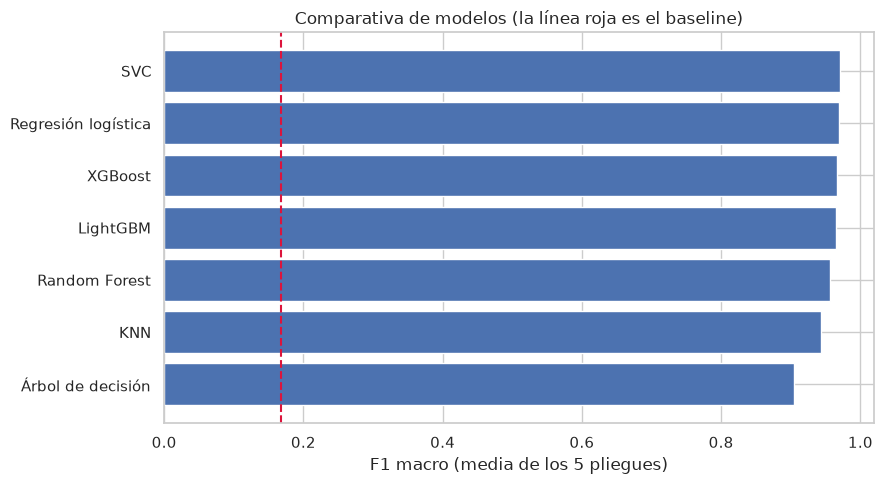

In [41]:
orden = comparativa.sort_values("f1_macro")

plt.figure(figsize=(9, 5))
plt.barh(orden["modelo"], orden["f1_macro"])
plt.axvline(f1_baseline.mean(), color="crimson", linestyle="--")
plt.xlabel("F1 macro (media de los 5 pliegues)")
plt.title("Comparativa de modelos (la línea roja es el baseline)")
plt.tight_layout()
plt.savefig("src/img/paso11_comparativa.png", dpi=120)
plt.show()

- **Todos los modelos superan con mucho al baseline** (0,168).
- **SVC (0,971), regresión logística (0,969), XGBoost (0,966) y LightGBM (0,965) quedan prácticamente empatados.** La diferencia entre el primero y el cuarto es menor que lo que varía cada uno de un pliegue a otro, con desviaciones entre 0,024 y 0,033.
- El árbol de decisión es el más flojo (0,904) y el más irregular (0,064).

## Paso 12: Optimización de hiperparámetros

Se optimizan dos de los modelos empatados, uno de cada familia:

- **Regresión logística:** se busca la fuerza de la regularización `C` con `GridSearchCV`, porque tiene un solo parámetro importante.
- **XGBoost:** con `RandomizedSearchCV`, porque tiene muchos parámetros y probar todas las combinaciones sería muy lento.

Si después de optimizar quedan parecidos, se elige la regresión logística, porque sus coeficientes muestran qué señales distinguen a cada perro, que es lo que pide el plan de acción.

In [42]:
grid_logistica = GridSearchCV(LogisticRegression(max_iter=1000),
                              param_grid={"C": [0.001, 0.01, 0.1, 1, 10, 100]},
                              cv=5, scoring="f1_macro")
grid_logistica.fit(X_train_scaled, y_train)

print("Mejor C:", grid_logistica.best_params_["C"])
print("F1 macro:", round(grid_logistica.best_score_, 3))

Mejor C: 0.1
F1 macro: 0.969


La mejor regularización es C = 0,1, con un F1 macro de 0,969: el mismo resultado que con los parámetros por defecto en la comparativa.

In [43]:
parametros_xgboost = {
    "max_depth": [2, 3, 4, 6],
    "learning_rate": [0.05, 0.1, 0.2, 0.3],
    "n_estimators": [50, 100, 200, 400],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}
busqueda_xgboost = RandomizedSearchCV(XGBClassifier(random_state=42), param_distributions=parametros_xgboost,
                                      n_iter=30, cv=5, scoring="f1_macro", random_state=42)
busqueda_xgboost.fit(X_train, y_train)

print("Mejores parámetros:", busqueda_xgboost.best_params_)
print("F1 macro:", round(busqueda_xgboost.best_score_, 3))

Mejores parámetros: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
F1 macro: 0.971


XGBoost mejora algo con la búsqueda: pasa de 0,966 con los parámetros por defecto a 0,971.

In [44]:
print(f"Regresión logística: F1 macro {grid_logistica.best_score_:.3f}")
print(f"XGBoost:             F1 macro {busqueda_xgboost.best_score_:.3f}")

modelo_final = grid_logistica.best_estimator_

Regresión logística: F1 macro 0.969
XGBoost:             F1 macro 0.971


Quedan prácticamente empatados (0,969 frente a 0,971), así que **el modelo final es la regresión logística con C = 0,1.**

## Paso 13: Evaluación contra test

El modelo final se evalúa **una sola vez** con los 118 días de agosto y septiembre, que no ha visto en ningún momento. `GridSearchCV` ya lo reentrenó con todo train después de elegir `C`.

In [45]:
y_pred = modelo_final.predict(X_test_scaled)

print(f"F1 macro: {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=PERROS))

F1 macro: 0.983
Accuracy: 0.983

              precision    recall  f1-score   support

      cherry       0.95      1.00      0.98        40
        coco       1.00      1.00      1.00        39
        plum       1.00      0.95      0.97        39

    accuracy                           0.98       118
   macro avg       0.98      0.98      0.98       118
weighted avg       0.98      0.98      0.98       118



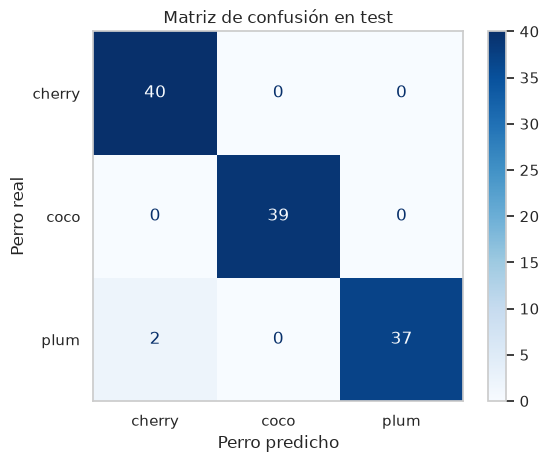

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=PERROS, cmap="Blues")
plt.title("Matriz de confusión en test")
plt.xlabel("Perro predicho")
plt.ylabel("Perro real")
plt.grid(False)
plt.savefig("src/img/paso13_matriz_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

- **F1 macro de 0,983 y accuracy de 0,983 en test**, en línea con la validación cruzada (0,969). Con 118 días, cada error mueve el resultado casi un punto.
- **Todos los días de coco y de cherry se reconocen bien.**
- **Los únicos 2 errores son días de plum reconocidos como cherry.**

### ¿Qué pasó en esos dos días?

In [47]:
dias_error = test_set[y_pred != y_test.values]

comparacion = dias_error[FEATURES].T
comparacion.columns = ["plum " + str(fecha.date()) for fecha in dias_error["fecha"]]
comparacion["mediana plum (train)"] = train_set[train_set[TARGET] == "plum"][FEATURES].median()
comparacion["mediana cherry (train)"] = train_set[train_set[TARGET] == "cherry"][FEATURES].median()
comparacion.round(1)

,plum 2026-09-05,plum 2026-09-06,mediana plum (train),mediana cherry (train)
pct_calma,4.5,4.5,4.4,4.5
pct_activo,8.5,8.9,9.9,8.9
fc_media,59.2,61.2,63.0,58.4
fc_max,124.0,106.0,96.0,92.0
fr_media,14.3,13.2,9.7,11.2
fr_min,7.0,7.0,7.0,6.0
fr_max,55.0,97.0,21.0,26.0
ladridos_total,8.0,2.0,4.0,115.0
ladridos_franjas,4.0,2.0,3.0,11.0


In [48]:
agosto = test_set[test_set["fecha"] < "2026-09-01"]
septiembre = test_set[test_set["fecha"] >= "2026-09-01"]

print("Frecuencia respiratoria media (mediana) por periodo:")
for perro in ["plum", "cherry"]:
    valores = []
    for periodo in [train_set, agosto, septiembre]:
        valores.append(periodo[periodo[TARGET] == perro]["fr_media"].median())
    print(f"  {perro}: train {valores[0]:.1f} | agosto {valores[1]:.1f} | septiembre {valores[2]:.1f}")

Frecuencia respiratoria media (mediana) por periodo:
  plum: train 9.7 | agosto 12.4 | septiembre 11.3
  cherry: train 11.2 | agosto 14.6 | septiembre 14.2


Los dos días plum ladró poco, como siempre, pero sus constantes se parecían más a las de cherry: la frecuencia respiratoria estaba muy por encima de lo habitual (14,3 y 13,2, frente a una mediana de 9,7, e incluso por encima de la de cherry, 11,2) y la cardíaca, por debajo (59,2 y 61,2, frente a 63,0).

La frecuencia respiratoria sube en agosto y septiembre en los dos perros (plum pasa de 9,7 a 12,4 y 11,3; cherry, de 11,2 a 14,6 y 14,2), en línea con lo visto en H2: en los meses cálidos la FR es más alta. El modelo aprendió con días de marzo a julio y, cuando las constantes cambian con la época, un día de un perro puede parecerse a los de otro. Es el riesgo que anticipaba el EDA.

### ¿Qué señales distinguen a cada perro?

Los coeficientes de la regresión logística indican qué variables acercan un día a cada perro (valores positivos) o lo alejan (negativos). Como los datos están escalados, se pueden comparar entre variables.

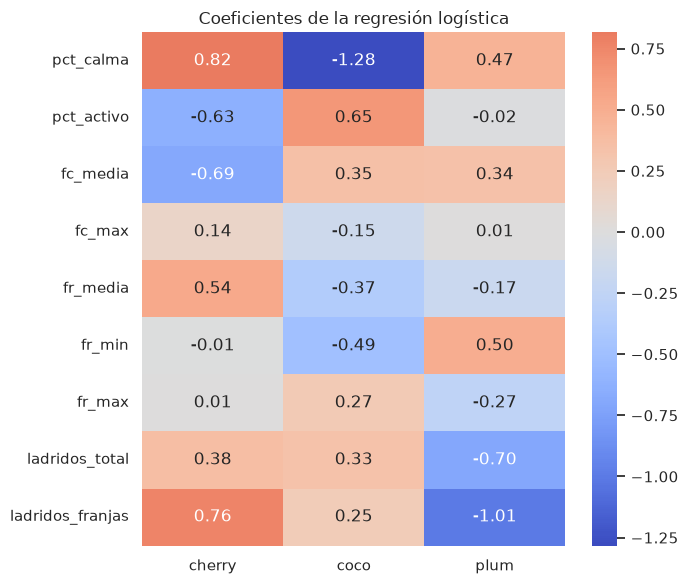

,cherry,coco,plum
pct_calma,0.82,-1.28,0.47
pct_activo,-0.63,0.65,-0.02
fc_media,-0.69,0.35,0.34
fc_max,0.14,-0.15,0.01
fr_media,0.54,-0.37,-0.17
fr_min,-0.01,-0.49,0.50
fr_max,0.01,0.27,-0.27
ladridos_total,0.38,0.33,-0.70
ladridos_franjas,0.76,0.25,-1.01


In [49]:
coeficientes = pd.DataFrame(modelo_final.coef_, index=PERROS, columns=FEATURES).T

plt.figure(figsize=(7, 6))
sns.heatmap(coeficientes, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Coeficientes de la regresión logística")
plt.tight_layout()
plt.savefig("src/img/paso13_coeficientes.png", dpi=120)
plt.show()

coeficientes.round(2)

| Perro | Lo que más lo caracteriza |
|---|---|
| **plum** | pocos ladridos, repartidos en pocas franjas (−1,01) y en poca cantidad (−0,70) |
| **coco** | poco tiempo en calma (−1,28) y más tiempo activo (0,65) |
| **cherry** | más tiempo en calma (0,82), ladridos repartidos en más franjas (0,76) y frecuencia cardíaca más baja (−0,69) |

Encaja con el EDA: la FC no separaba a coco de plum (H1), y el modelo los distingue por los ladridos y la actividad. `fc_max` apenas pesa en ningún perro. Estas son las señales que conviene vigilar en los avisos de cada uno.

## Paso 14: Conclusiones y acciones de mejora

### Respuesta al problema

**Sí: con un día de datos del collar se reconoce a cada perro casi siempre** (F1 macro de 0,983 en días que el modelo no había visto). El EDA mostró que cada perro tiene un nivel propio en sus señales, aunque ninguna señal sola separa a los tres, y el modelo confirma que combinadas bastan.

Según el plan de acción, eso justifica **avisos personalizados** basados en la referencia de cada perro y centrados en sus señales más características: los ladridos en plum, el tiempo en calma y activo en coco, y la calma, la frecuencia cardíaca y el reparto de los ladridos en cherry.

### Limitaciones

- **Tres perros de una misma casa:** el resultado no se puede generalizar a otros perros.
- **Perro y collar van siempre juntos:** aunque los tres collares son del mismo modelo, no se puede descartar que el modelo reconozca en parte diferencias entre unidades.
- **Pocos meses de datos:** el modelo no ha visto ni otoño ni invierno.
- **Las constantes cambian con la época del año:** los dos errores coinciden con días en que las de plum se acercaron a las de cherry.
- **El significado de las categorías de actividad se ha deducido de los datos**; el fabricante no lo documenta.
- **La detección de días atípicos sigue sin validar**, por falta de un historial de problemas de salud.

### Acciones de mejora

- **Reentrenar el modelo con datos de otoño e invierno**, y después de forma periódica.
- **Comparar cada perro con su referencia de la misma época** al montar los avisos.
- **Usar la temperatura de una estación meteorológica cercana**, para separar el efecto del calor del de la época del año (H2).
- **Intercambiar los collares unos días** como experimento: si las predicciones siguen al perro, el modelo reconoce perros; si siguen al collar, reconoce collares.
- **Registrar las visitas al veterinario y los problemas de salud**, para poder validar en el futuro la detección de días atípicos.

## Paso 15: Guardado del modelo

Se guardan el modelo final y el escalador, porque para usar el modelo con un día nuevo hay que escalar sus datos igual que en el entrenamiento. Para predecir hacen falta las columnas de `FEATURES` en ese orden, y la predicción se traduce con `PERROS`: 0 es cherry, 1 es coco y 2 es plum.

In [50]:
with open("src/models/modelo_final.pkl", "wb") as archivo:
    pickle.dump(modelo_final, archivo)
with open("src/models/scaler.pkl", "wb") as archivo:
    pickle.dump(scaler, archivo)
print("Guardados: src/models/modelo_final.pkl y src/models/scaler.pkl")

Guardados: src/models/modelo_final.pkl y src/models/scaler.pkl


In [51]:
with open("src/models/modelo_final.pkl", "rb") as archivo:
    modelo_cargado = pickle.load(archivo)
with open("src/models/scaler.pkl", "rb") as archivo:
    scaler_cargado = pickle.load(archivo)

X_test_nuevo = pd.DataFrame(scaler_cargado.transform(X_test), columns=FEATURES)
prediccion = modelo_cargado.predict(X_test_nuevo)
print("¿El modelo cargado da las mismas predicciones que el original?", (prediccion == y_pred).all())

¿El modelo cargado da las mismas predicciones que el original? True
